# Introduction


Wildfires are devastating to communities, as they destroy homes, infrastructure, and natural environments. This homework assignment will focus on devloping and evaluating predictive models utilizing data from the California Department of Forestry and Fire Porctection (CAL FIRE). CAL FIRE provides essential services including fire prevention, emergency response, and natural resource protection throughout California. The primary goal of this analysis is to leverage CAL FIRE's Damage Inspection (DINS) dataset, specifically targeting the prediction of structural damage risk resulting from wildland fires. Our dataset is a sampled subset of CAL FIRE's publicly available records, focusing on structures categorized explicitly as either "No Damage" or "Destroyed (>50%)". By analyzing this data, we aim to identify and model the relationship between various descriptive features and the target variable, DAMAGE. Through the application of data analytics methods covered in lectures and labs, this assignment involves preparing the data appropriately and systematically building and assessing predictive models. Ultimately, these models aim to reliably forecast structural damage risk, enhancing future response and mitigation strategies.

# Part 0: Preprocessing Data 

Before starting in Homework 2 I thought it would be best to take the original raw csv data I was given in Homework 1 and make changes and adjustments based off the soultions and suggestions given by the professors Data Quality Plan. This way I can start my second homework assingment knowing that the data was cleaned the suggested way. In the zip file I turn in I will have folder labled "Data" within it I will have data labled as "cal-wildfires-24214616.csv" (orginal data) and "enhanced_wildfire_data.csv" (cleaned data) in order to not have any confusion. Below you can find the code to clean the raw dataset according to the suggestions of the professor's DQP. Since the DQP is alreay known I will not spend time justifying why I cleaned the data the way I did, I will just have comments so anyone reading this can understand what I am doing, I will however explain and justify any extra actions I take to further enhance the data.

In [1]:
import pandas as pd 
import re
from IPython.display import display
import numpy as np
from datetime import date
import os

# load the og raw wildfire data
file_path = "data/cal-wildfires-24214616.csv"
df = pd.read_csv(file_path)

# 1. this is the function to clean and standardize column names according to the DQP given
def clean_col(col):
    col = col.strip()                  # Remove leading/trailing whitespace
    col = re.sub(r'^\*\s*', '', col)   # Drop leading asterisk if present
    col = re.sub(r'\s*\(.*?\)', '', col)  # Remove parentheses and content within
    col = col.replace('/', '_')        # Replace slashes with underscores
    col = col.replace(' ', '_')        # Replace spaces with underscores
    col = col.replace('.', '')         # Remove periods
    col = col.replace('-', '_')        # replaces any - with _
    col = re.sub(r'_+', '_', col)      # collapse multi underscores    
    return col

#this will apply the renaming 
df.columns = [clean_col(c) for c in df.columns]

# 2. Drop constant/irrelevant features per DQP
drop_cols = [
    'Hazard_Type',  # constant
    'State',        # constant
    'Community',    # irrelevant overlap with City
    #'Site_Address', will need this later for ZIP code hence I will now drop this after that Imputation
    'Street_Number', #Same as site_addresss and below 
    'Street_Name',
    'Street_Type'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# 3. Remove duplicate rows ignoring OBJECTID
subset_cols = [c for c in df.columns if c != 'OBJECTID']
before_dedup = df.shape[0]
df = df.drop_duplicates(subset=subset_cols)
after_dedup = df.shape[0]


# 4. Date handling: convert Incident_Start_Date to date only (drop time component)
df['Incident_Start_Date'] = pd.to_datetime(
    df['Incident_Start_Date'],
    errors='coerce'            # leave unparseable as NaT
).dt.date 

print("Parsed dates (non-null):", df['Incident_Start_Date'].notna().sum())

#filter post 2018
df = df[df['Incident_Start_Date'] >= pd.to_datetime('2018-01-01').date()].copy()

#Derive Date features
df['Incident_Month']   = pd.to_datetime(df['Incident_Start_Date']).dt.month
df['Incident_Season']  = df['Incident_Month'].map(
    lambda m: 'Winter' if m in [12,1,2]
              else 'Spring' if m in [3,4,5]
              else 'Summer' if m in [6,7,8]
              else 'Fall'
)
df['Incident_Weekday'] = pd.to_datetime(df['Incident_Start_Date']).dt.weekday
df['Building_Age']     = pd.to_datetime(df['Incident_Start_Date']).dt.year - df['Year_Built']

# 5. Categorical Cleaning per DQP

# 5a. Structure_Defense_Actions_Taken: fill missing with 'Unknown'
df['Structure_Defense_Actions_Taken'] = (
    df['Structure_Defense_Actions_Taken']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace(r'^\s*$', 'Unknown', regex=True)
)

# 5b. Eaves: merge 'Not Applicable' & blanks into 'No Eaves'
df['Eaves'] = (
    df['Eaves']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({'Not Applicable': 'No Eaves', '': 'Unknown'})
)

# 5c. City: trim, title-case, merge synonyms, handle 'Paradise'
df['City'] = (
    df['City']
    .astype(str)
    .str.strip()
    .replace({'N/a': 'Unknown', 'N/A': 'Unknown', '': 'Unknown'})
    .str.title()
)
df['City'] = df['City'].replace({'Johnson Dale': 'Johnsondale'})
df.loc[df['City'].str.contains('Paradise', case=False, na=False), 'City'] = 'Paradise'
df['City'] = df['City'].fillna('Unknown')

# 5d. Distance_Residence_to_Utility_Misc_Structure: rename & merge categories
old_col = 'Distance_-_Residence_to_Utility_Misc_Structure_&_gt;_120_SQFT'
# handle HTML entity in column name
alternatives = [c for c in df.columns if 'Residence_to_Utility' in c]
col_name = alternatives[0]  # actual name
df = df.rename(columns={col_name: 'Distance_Residence_to_Utility_Misc_Structure'})
df['Distance_Residence_to_Utility_Misc_Structure'] = (
    df['Distance_Residence_to_Utility_Misc_Structure']
    .fillna('Unknown')
    .astype(str)
    .replace({"<30'": '<30', '30': '<30', ">50'": '>50', '50': '>50', "30-50'": '30-50'})
)

# 6. will now handle outliers for numerical fields
# 6a. Examine the distribution of Assessed_Improved_Value
stats = df['Assessed_Improved_Value'].describe()

# 6b. Determine an outlier threshold (99th percentile)
threshold = df['Assessed_Improved_Value'].quantile(0.99)

# 6c. Flag values above this threshold as outliers
outlier_mask = df['Assessed_Improved_Value'] > threshold

# 6d. Create a 'Known' indicator: True if value is neither missing nor an outlier
df['Assessed_Improved_Value_Known'] = (~df['Assessed_Improved_Value'].isna()) & (~outlier_mask)

# 6e. Set outlier and missing values to 0
df.loc[~df['Assessed_Improved_Value_Known'], 'Assessed_Improved_Value'] = 0

# 7. Define plausible Year_Built range
valid_min = 1800
valid_max = 2025

# 7a. Flag known values: non-missing and within the plausible range
mask_valid = df['Year_Built'].between(valid_min, valid_max)
mask_known = df['Year_Built'].notna() & mask_valid
df['Year_Built_Known'] = mask_known

# 7b. Impute missing or outlier years with median of known values
median_year = int(df.loc[mask_known, 'Year_Built'].median())
df.loc[~mask_known, 'Year_Built'] = median_year

# 8. Will now filter out pre-2018 rows Removed all incidents occurring before 2018 to address 
# irregularities and inconsistencies specifically documented in Roof_Construction, Vent_Screen, and Exterior_Siding

#Filter out any incidents before 2018-01-01
cutoff = date(2018, 1, 1)
df_pre2018_removed = df[df['Incident_Start_Date'] >= cutoff]

# 9. Imputing ZIP codes according to DQP and will finally drop site address
# Identify rows where Zip_Code is missing
mask_missing = df['Zip_Code'].isna()

# Function to extract a 5-digit ZIP from the Site_Address string
def extract_zip(addr):
    if isinstance(addr, str):
        match = re.search(r'\b(\d{5})\b', addr)
        if match:
            return match.group(1)
    return None

# Apply extraction to missing ZIPs
extracted = df.loc[mask_missing, 'Site_Address'].apply(extract_zip)

#  Assign extracted ZIPs and create an 'Imputed' flag
df.loc[mask_missing & extracted.notna(), 'Zip_Code'] = extracted.astype(float)
df['Zip_Code_Imputed'] = mask_missing & extracted.notna()

# Will now proceed to drop Site Address since this is not needed any longer
drop_cols = [ 'Site_Address' ]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# 9. Filling in missing county values with unknown
df['County'] = df['County'].fillna('Unknown')

# 10. Structure_Category imputation 
df['Structure_Category'] = df['Structure_Type']

# 11. Inferring the number of units from structure_type
def infer_units(stype):
    if pd.isna(stype):
        return np.nan
    s = stype.lower()
    if 'single family' in s or 'mobile home' in s: return 1
    if 'duplex' in s:      return 2
    if 'triplex' in s:     return 3
    if 'fourplex' in s or '4-plex' in s: return 4
    return np.nan
df['#_Units_in_Structure'] = (
    df['Structure_Type']
      .apply(infer_units)
      .fillna('Unknown')
)

# 12.  Ensure Latitude and Longitude are numeric
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# 12a. Apply geographic bounds filter for California
mask = df['Latitude'].between(32, 42) & df['Longitude'].between(-125, -113)
df_filtered = df[mask]


Parsed dates (non-null): 10000


C:\Users\anar2\AppData\Local\Temp\ipykernel_9660\769751668.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Incident_Start_Date'] = pd.to_datetime(


## Part 0.1 Enhanced Suggestions

Below you will find extra coding that I thought would be necessary for preprocessing the data both of which are a mixture of the enhanced suggestions from the sample Homework 1 DQP and from my own previous homework 1 that I think will be helpful in setting up my data for Homework 2's training and testing. 

1. Check distribution and rebalance the target variable (Damage)
Reason:
Predictive models can struggle with severely imbalanced classes. Evaluating and, if needed, rebalancing the target improves model robustness, generalization, and ensures fairer performance evaluation—especially for minority classes.

2. Temporal features derived from Incident_Start_Date
Reason:
Fires are typically seasonal and exhibit temporal patterns. Temporal features (month, season, weekday) capture these inherent periodic behaviors, potentially improving model performance.

3. Standardization/grouping of CAL_FIRE_Unit
Reason:
CAL FIRE units often correlate geographically with fire patterns. Grouping units reduces dimensionality and ensures meaningful geographic insights without redundancy or multicollinearity.

4. Log-transform and impute Assessed_Improved_Value
Reason:
Property values generally follow a skewed distribution. Log transformation stabilizes variance, normalizes distributions, and enhances the effectiveness of algorithms sensitive to scale (e.g., linear models).

5. Deriving Building_Age from Year_Built
Reason:
Building age is directly associated with construction standards, materials, and fire safety practices. Older buildings often have higher fire vulnerability, making age a strong predictive feature.

6. Simplifying Structure_Type
Reason:
Rare categories increase model complexity and reduce statistical power. Grouping them into broader categories improves robustness and generalizability.

7. Grouping Roof_Construction, Exterior_Siding, Vent_Screen, and Window_Pane
Reason:
Building materials significantly impact fire spread and severity. Grouping similar materials simplifies the feature space and improves interpretability and predictive performance.

8. Binary indicators and composite risk (Deck/Porch/Patio/Fence)
Reason:
The presence and material of external features influence fire spread. Binary indicators clearly distinguish risk presence, and combining these into a vulnerability score improves predictive insights.

9. Distance-based binary risk indicators (Distance_Propane_Tank, Distance_Utility_Structure)
Reason:
Proximity to combustible or hazardous structures directly increases fire risk. Binary risk indicators simplify understanding and improve model clarity and interpretability.

10. Extract Zip prefix and fill missing modes per city or county
This reduces the number of unique ZIP while retaining regional locality and will imputate based on patterns seen

11. Geospatial-derived features (Latitude, Longitude)
Reason:
Geographic location strongly influences fire risk (terrain, weather patterns, proximity to natural firebreaks). These features enrich spatial understanding and significantly boost predictive capabilities.



In [2]:
# 1. Check Damage distribution
damage_counts = df['Damage'].value_counts()
print("Damage Distribution:\n", damage_counts)

# 2. Extract temporal features
#  Ensure “Incident_Start_Date” is a datetime64 dtype
df['Incident_Start_Date'] = pd.to_datetime(df['Incident_Start_Date'], errors='coerce')

# Derive Incident_Month, Incident_Season, Incident_Weekday
df['Incident_Month'] = df['Incident_Start_Date'].dt.month

df['Incident_Season'] = df['Incident_Month'].apply(
    lambda x: (
        'Winter' if x in [12, 1, 2] else
        'Spring' if x in [3, 4, 5] else
        'Summer' if x in [6, 7, 8] else
        'Fall'
    )
)
df['Incident_Weekday'] = df['Incident_Start_Date'].dt.weekday

# 3. Standardizing/grouping CAL_FIRE_Unit (example grouping by region prefix)
df['CAL_FIRE_Region'] = df['CAL_FIRE_Unit'].str.split('-').str[0]

# 4. Log-transform Assessed_Improved_Value
df['Log_Assessed_Improved_Value'] = np.log1p(df['Assessed_Improved_Value'])

# 5. Building_Age derived from Year_Built
df['Building_Age'] = pd.to_datetime(df['Incident_Start_Date']).dt.year - df['Year_Built']

# 6. Simplifying Structure_Type
simplified_types = {
    'Single Family Residence': 'Single_Family',
    'Mobile Home': 'Mobile_Home',
    'Duplex': 'Multi_Family',
    'Triplex': 'Multi_Family',
    'Apartment': 'Multi_Family',
    'Other': 'Other'
}
df['Structure_Type_Simplified'] = df['Structure_Type'].replace(simplified_types).fillna('Other')

# 7. Roof Construction Material Grouping
roof_groups = {
    'Wood Shake': 'Wood',
    'Asphalt Shingle': 'Composite',
    'Metal': 'Metal',
    'Tile': 'Tile',
    'Unknown': 'Unknown'
}
df['Roof_Material_Group'] = df['Roof_Construction'].replace(roof_groups).fillna('Unknown')

# 8. Binary Indicators and composite risk
df['Has_Deck'] = df['Deck_Porch_On_Grade'].apply(lambda x: 0 if x in ['None', 'Unknown'] else 1)
df['Has_Elevated_Deck'] = df['Deck_Porch_Elevated'].apply(lambda x: 0 if x in ['None', 'Unknown'] else 1)
df['Has_Attached_Patio'] = df['Patio_Cover_Carport_Attached_to_Structure'].apply(lambda x: 0 if x in ['None', 'Unknown'] else 1)
df['Has_Fence'] = df['Fence_Attached_to_Structure'].apply(lambda x: 0 if x in ['None', 'Unknown'] else 1)

#  Impute missing Fence_Attached_to_Structure with "Unknown"
df['Fence_Attached_to_Structure'] = df['Fence_Attached_to_Structure'].fillna('Unknown')


# Composite vulnerability score example
df['Exterior_Vulnerability_Score'] = df[['Has_Deck', 'Has_Elevated_Deck', 'Has_Attached_Patio', 'Has_Fence']].sum(axis=1)

# 9 Binary flags for Distance to propane
df['Propane_Tank_Near'] = df['Distance_Propane_Tank_to_Structure'].apply(
    lambda x: 1 if x in ['0-10', '11-20', '21-30'] else 0
)
df['Utility_Structure_Near'] = df['Distance_Residence_to_Utility_Misc_Structure'].apply(
    lambda x: 1 if x in ['0-10', '11-20', '21-30'] else 0
)


# 10 convert xip code to string and get 3 digits and fill in missing zip prefix using mode per city
df['Zip_Prefix'] = df['Zip_Code'].apply(
lambda x: str(int(x))[:3] if not pd.isnull(x) else 'nan'
)

def fill_zip_prefix(row):
    if row['Zip_Prefix'] == 'nan':
        city = row['City']
        if pd.notnull(city):
            # Get mode for this city
            city_mode = df[df['City'] == city]['Zip_Prefix'].mode()
            if not city_mode.empty:
                return city_mode[0]
    return row['Zip_Prefix']
df['Zip_Prefix'] = df.apply(fill_zip_prefix, axis=1)

# 11. Geospatial derived features (example: simple regional clustering)
df['Region_Cluster'] = pd.cut(df['Latitude'], bins=[32,35,38,42], labels=['South','Central','North'])

print(df[['Building_Age','Incident_Weekday','Incident_Month']].isna().mean())

# export into data/
df.to_csv('data/enhanced_wildfire_data.csv', index=False)
print("Enhanced dataset exported to data/enhanced_wildfire_data.csv")

Damage Distribution:
 Damage
Destroyed (>50%)    4479
No Damage           4260
Name: count, dtype: int64
Building_Age        0.0
Incident_Weekday    0.0
Incident_Month      0.0
dtype: float64
Enhanced dataset exported to data/enhanced_wildfire_data.csv


# Homework 2 Starts Here


Just a reminder I will be now using enhanced_wildfire_data.csv to complete homework 2! 

# Part 1:

 **Data Understanding and Preparation:** Exploring relationships between feature pairs and selecting/transforming promising features based on a given training set.

## (1.1)  

Split the dataset into two datasets: 70% training and 30% test. Keep the test set aside. 

For transparency I used the enhanced csv that I created above to start my homework 2.

From observation it confirms that there was a successful stratified split, meaning the model training and evaluation will be based on similarly distributed data.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = "data/enhanced_wildfire_data.csv"
df = pd.read_csv(file_path)

# this will split the data into 70% training and 30% testing
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['Damage'],
    random_state=42
)

# Check the sizes and the class balance in both sets
train_size = len(train_df)
test_size = len(test_df)
train_distribution = train_df['Damage'].value_counts(normalize=True) * 100
test_distribution = test_df['Damage'].value_counts(normalize=True) * 100

(train_size, test_size), train_distribution, test_distribution

((6117, 2622),
 Damage
 Destroyed (>50%)    51.250613
 No Damage           48.749387
 Name: proportion, dtype: float64,
 Damage
 Destroyed (>50%)    51.258581
 No Damage           48.741419
 Name: proportion, dtype: float64)

## (1.2)

## (1.2.1) 

**Plot the correlations between all the continuous features (if any). Discuss what you observe in these plots.**

Correlation measures the linear relationship between two numerical variables.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


file_path = "data/enhanced_wildfire_data.csv"
wildfire_data = pd.read_csv(file_path)

# Redo cleaning steps for categorical plotting
wildfire_data['Zip_Prefix'] = wildfire_data['Zip_Code'].apply(lambda x: str(int(x))[:3] if not pd.isnull(x) else 'nan')
def fill_zip_prefix(row):
    if row['Zip_Prefix'] == 'nan':
        city = row['City']
        if pd.notnull(city):
            city_mode = wildfire_data[wildfire_data['City'] == city]['Zip_Prefix'].mode()
            if not city_mode.empty:
                return city_mode[0]
    return row['Zip_Prefix']
df['Zip_Prefix'] = df.apply(fill_zip_prefix, axis=1)
df['Fence_Attached_to_Structure'] = df['Fence_Attached_to_Structure'].fillna('Unknown')


# Split data again
train_df_final, test_df_final = train_test_split(
    df,
    test_size=0.3,
    stratify=df['Damage'],
    random_state=42
)

# categorical features for plotting
categorical_features = [
    'Structure_Type_Simplified',
    'Roof_Material_Group',
    'CAL_FIRE_Region',
    'Has_Deck',                 # binary but they are still categorical in behavior
    'Has_Elevated_Deck',        # binary but they are still categorical in behavior
    'Has_Attached_Patio',       # binary but they are still categorical in behavior
    'Has_Fence',                # binary but they are still categorical in behavior
    'Region_Cluster',
    'Structure_Defense_Actions_Taken',
    'Structure_Category',
    'Patio_Cover_Carport_Attached_to_Structure',
    'Fence_Attached_to_Structure'
]

# Create the plots
sns.set_theme(style="whitegrid")
n = len(categorical_features)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 5 * n))

for idx, col in enumerate(categorical_features):
    sns.countplot(
        data=train_df_final,
        x=col,
        hue='Damage',
        ax=axes[idx],
        palette='Set2'
    )
    axes[idx].set_title(f"{col} vs Damage", fontsize=14)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    axes[idx].tick_params(axis='x', rotation=70)
plt.subplots_adjust(hspace=0.6)
plt.tight_layout()
plt.show()


## (1.2.3) Key Features
The goal of this section is to plot the distrubtions of each categorical feature against the target varible Damage and see which one shows a strong seperation between destroyed and no damage. For that reason I will use stacked bar plots for each categorical feature because this helps see the class separation, and identiy dominate vs rare categories. I adjusted the figure layout with vertical spacing (hspace=0.6) and rotated x-axis labels by 90° to ensure readability across subplots with many categories. This made the plots visually clearer and easier to interpret for reporting and analysis. Below are my observations on these categorical features:

1) Structure_Type_Simplifed:
There is a huge difference in class distributions here, and some structure types like single-family homes shows a higher share of destruction, while others are moderatly safe. I believe this would be a very strong predictor.

2) Roof_Material_Group:
For this one there is a clear seperation between classes showing that some roof materials liek tile tend to be less damaged compared to others, due to this I belive this is another strong predictor.

3) CAL_FIRE_Region and Region_Cluster
This shows that regional differences have more structures destroyed than others and suggests that gegraphic factors are influential.

4) Structure_Defense_Action_Taken
The plot shows that structures where defense actions were taken appear more likely to survive. This suggests it could be a useful predictive feature. However, it's important to interpret this carefully—this correlation does not necessarily imply causation. It is possible that such defensive actions were more commonly taken in high-risk areas, meaning the feature may reflect prior risk awareness rather than actual protective effectiveness.

Moderate Indicators: 

1) Has_deck, Has_Elevated_Deck, Has_Attached_Patio: 
This could be marginally predictive due to having some more damage towards homes with these features, however overlap exists.

2) Fence_Attached_to_Structure: 
This may also have some predictive value due to certain fence types or Unknown that show more damage than others.

While reviewing the plots, it's evident that some categorical features have highly imbalanced distributions. For instance, categories like Has_Elevated_Deck = Yes or uncommon roof materials are relatively rare. These low-frequency categories could introduce bias during model training.

Weak Indicator: 

1) Structure_Category:
From ym observations distribution looks fairly  even between damage types across categories, and I have concluded that it may not add much on its own. 

## (1.2.3.1)  Selected Categorical featute
Based on the count plots and contextual knowledge of wildfire risk factors, I selected the following categorical features as promising predictors of Damage: 

**Structure_Type_Simplified** becuse it shows a very strong seperation between damnage classses in the count plot. There are clear signals meaning that they have great features. 


**Roof_Material_Group** was picked because roofing materials like tiles vs asphalt showed very distinct damage distributions showing that some were more resistant. 


**CAL_FIRE_Region** this reflects geogrpahic fire zones. Regional differences in damage were obvious and I believe good for capturing location-related risk.   


**Structure_Defense_Action_Taken** The plots above showed that active defense efforts are associated with lower destruction and can add to predictive context.


**Fence_Attached_to_Structure** some categories for this has higher destruction rates I think if it is combined with other fire-spread features it may be very useful.


**Has_Deck, Has_Fence, and Has_Elevated_Deck** these binary flags showed moderate but I believe meaningful trends. Homes with these featuers tended to suffer more damage, once again this may not be strong alone, but could be useful in other models.
These features were chosen based on both visual separation in the exploratory analysis and logical fire-related risk relevance. Features with weaker or redundant signals were excluded to streamline the model.
      

# Part 2:

**Predictive Modeling:** Linear Regression.  

## (2.1)

 On the training set, train a linear regression model to predict the target feature, using only the  descriptive features selected in exercise (1) above. 

 Descriptive Features: 

 Categorical: Structure_Type_Simplified, Roof_Material_Group, CAL_FIRE_Region, Structure_Defense_Actions_Taken, Fence_Attached_to_Structure, Has_Deck, Has_Fence, Has_Elevated_Deck

 Continuous: Building_Age, Log_Assessed_Improved_Value, Latitude, Longitude


In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
import seaborn as sns 

# Reload the enhanced wildfire dataset
file_path = "data/enhanced_wildfire_data.csv"
df = pd.read_csv(file_path)

# Recreate the 70/30 stratified split
train_df_final, test_df_final = train_test_split(
    df,
    test_size=0.3,
    stratify=df['Damage'],
    random_state=42
)

# Define the features 
categorical_features = [
    'Structure_Type_Simplified',
    'Roof_Material_Group',
    'CAL_FIRE_Region',
    'Structure_Defense_Actions_Taken',
    'Fence_Attached_to_Structure',
    'Has_Deck',
    'Has_Fence',
    'Has_Elevated_Deck'
]

continuous_features = [
    'Building_Age',
    'Log_Assessed_Improved_Value',
    'Latitude',
    'Longitude'
]

all_features = categorical_features + continuous_features

# Create binary target
train_df_final['Damage_Binary'] = train_df_final['Damage'].map({'Destroyed (>50%)': 1, 'No Damage': 0})
test_df_final['Damage_Binary'] = test_df_final['Damage'].map({'Destroyed (>50%)': 1, 'No Damage': 0})

# Extract feature sets
X_train = train_df_final[all_features]
y_train = train_df_final['Damage_Binary']
X_test = test_df_final[all_features]
y_test = test_df_final['Damage_Binary']

# Preprocessing and model pipeline
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[('cat', categorical_transformer, categorical_features)],
    remainder='passthrough'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train and predict
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE", mse)
print("MAE", mae)
print("r2", r2)


MSE 0.15145880035968143
MAE 0.3206937466849522
r2 0.3937806915264922


## (2.2)

Print the coefficients learned by the model and discuss their role in the model (e.g., interpret the model by analysing each coefficient and how it relates each input feature to the target feature).  


,Feature,Coefficient
44,CAL_FIRE_Region_SDU,0.838223
28,CAL_FIRE_Region_BTU,0.581445
51,Structure_Defense_Actions_Taken_Both,0.441360
0,Structure_Type_Simplified_Agriculture,0.376090
52,Structure_Defense_Actions_Taken_Civilian,0.311595
...,...,...
31,CAL_FIRE_Region_HUU,-0.365602
47,CAL_FIRE_Region_TCU,-0.392123
42,CAL_FIRE_Region_SBC,-0.422193
4,Structure_Type_Simplified_Hospital,-0.425951



 Top Categorical Features:



,Feature,Coefficient
44,CAL_FIRE_Region_SDU,0.838223
28,CAL_FIRE_Region_BTU,0.581445
51,Structure_Defense_Actions_Taken_Both,0.441360
0,Structure_Type_Simplified_Agriculture,0.376090
52,Structure_Defense_Actions_Taken_Civilian,0.311595
46,CAL_FIRE_Region_SKU,0.260223
34,CAL_FIRE_Region_LMU,0.246442
56,Structure_Defense_Actions_Taken_Fire Department,0.246177
9,Structure_Type_Simplified_Mobile Home Triple Wide,0.228779
30,CAL_FIRE_Region_FKU,0.227338



 Bottom Categorical Features:



,Feature,Coefficient
64,Fence_Attached_to_Structure_Unknown,-0.292352
58,Structure_Defense_Actions_Taken_Hand Crew Fuel...,-0.311992
29,CAL_FIRE_Region_CZU,-0.336667
36,CAL_FIRE_Region_MEU,-0.340315
17,Roof_Material_Group_,-0.358132
31,CAL_FIRE_Region_HUU,-0.365602
47,CAL_FIRE_Region_TCU,-0.392123
42,CAL_FIRE_Region_SBC,-0.422193
4,Structure_Type_Simplified_Hospital,-0.425951
27,CAL_FIRE_Region_BEU,-0.426043



Continuous Feature Coefficients:



,Feature,Coefficient
71,Building_Age,0.000294
72,Log_Assessed_Improved_Value,-0.001465
73,Latitude,-0.142817
74,Longitude,-0.201734


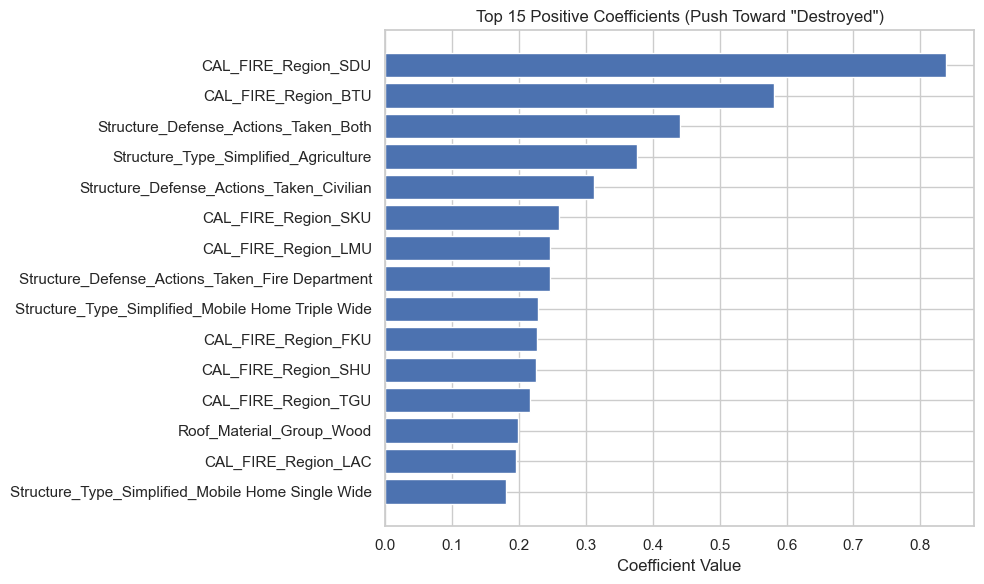

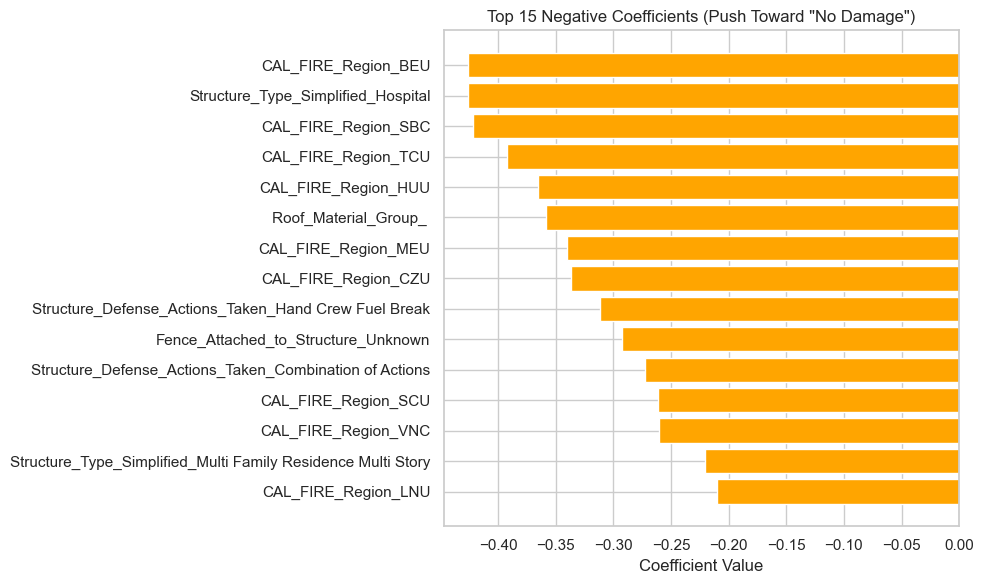

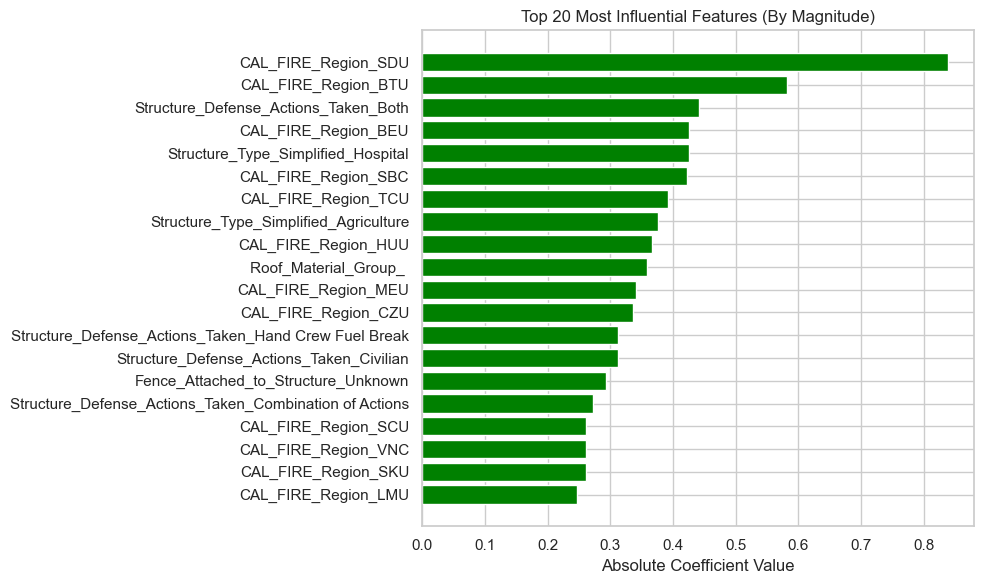

In [8]:
# 1. Get feature names after one-hot encoding
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

# 2. Combine encoded categorical and continuous feature names
final_feature_names = list(encoded_cat_features) + continuous_features

# 3. Extract coefficients
coefficients = model_pipeline.named_steps['regressor'].coef_

# 4. Create DataFrame of all features and their coefficients
coef_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# 5. Display full table
display(coef_df)

# 6. Separate for clearer interpretation
# a. Categorical only
cat_coef_df = coef_df[coef_df['Feature'].str.contains('_')]

# b. Continuous only (exact matches with continuous feature names)
cont_coef_df = coef_df[coef_df['Feature'].isin(continuous_features)]

print("\n Top Categorical Features:\n")
display(cat_coef_df.head(10))

print("\n Bottom Categorical Features:\n")
display(cat_coef_df.tail(10))

print("\nContinuous Feature Coefficients:\n")
display(cont_coef_df)

# Plotting Top Positive Coefficients
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_positive['Feature'], top_positive['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Positive Coefficients (Push Toward "Destroyed")')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plotting Top Negative Coefficients
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_negative['Feature'], top_negative['Coefficient'], color='orange')
plt.xlabel('Coefficient Value')
plt.title('Top 15 Negative Coefficients (Push Toward "No Damage")')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plotting Absolute Coefficients
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_abs = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_abs['Feature'], top_abs['Abs_Coefficient'], color='green')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Most Influential Features (By Magnitude)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



I used One-Hot Encoding so that my categorical features can be numerically represented in such a way that preserves thier id without introducing fake order or bias, this way the linear model can assign a coefficient to each category independently. 

The linear regression model assigns a coefficient to each input feature. Each coefficient indicates how a one-unit increase in that feature is expected to affect the predicted probability of damage while holding all other features constant. A positive coefficient means that the predicted chance of a structure being "Destroyed (>50%)" increases, whereas a negative coefficient decreases the predicted chance of damage. In essence, these coefficients reflect the direction and strength of the relationship between the feature and the likelihood of a structure being destroyed in a wildfire. With that in mind, here is my analysis of the coefficients:

The positive coefficients (ie the higher risk of destruction):


1) Cal_Fire_Reigionn_SDU (+0.84): This region demonstrated the strongest positive association with damage, indicating that structures located in SDU were significantly more likely to be destroyed compared to other areas.

2) Cal_Fire_Region_BTU (+0.58): The findings also revealed an elevated risk of damage, closely correlating with regions in California that are notorious for their susceptibility to wildfires.

3) Structure_Defense_Actions_Taken_Both (+0.44): Interestingly, the observation that both defense actions, namely those conducted by the fire department and those undertaken by civilians, are correlated with increased destruction suggests a deeper relationship. This correlation may imply that these defense actions are typically deployed only in response to extremely severe fire incidents. Consequently, the simultaneous use of both types of defense may serve as an indirect indicator of heightened risk levels, pointing to the severity and potential escalation of the fire situation at hand.

4) Structure_Type_Simplified_Agriculture (+0.38): Agricultural structures seem more susceptible to destruction by wildfires, likely due to insufficient fireproofing and lack of access to defense resources.

The negative coefficients (ie the lower risk of destruction): 

1) Structure_Type_Simplified_Hospital (−0.43): Hospitals tend to have a lower risk of destruction compared to other buildings. This resilience can be attributed to the implementation of stringent building codes that require robust construction materials and designs. Additionally, these facilities are equipped with advanced fire safety systems, including smoke detectors, sprinkler systems, and fire-resistant barriers, all of which play a crucial role in preventing damage during emergencies. 

2) CAL_FIRE_Region_BEU (−0.43) and CAL_FIRE_Region_SBC (−0.42): These regions were associated with reduced destruction, possibly due to lower fire incidence or better mitigation strategies.

Continuous Feature Analysis: 

1) Building_Age: Had a small positive coefficient, indicating that older structures are slightly more likely to be destroyed, likely due to outdated materials or lack of modern fireproofing.

2) Log_Assessed_Improved_Value: Showed a negative coefficient, suggesting that more valuable buildings are less likely to be destroyed — potentially because they’re better constructed or located in lower-risk areas.

3) Latitude and Longitude: These showed small effects, likely capturing subtle geographic trends related to fire risk. They were less influential than regional categories.



## (2.3)

Print the predicted target feature value for the first 10 training examples. Threshold the predicted target feature value given by the linear regression model at 0.5, to get the predicted class for each example. 

In [9]:
import numpy as np

# Predict on the first 10 training examples
first_10_preds = model_pipeline.predict(X_train[:10])  # continuous values
first_10_classes = (first_10_preds >= 0.5).astype(int)  # thresholded 

# Get true values
true_classes = y_train.iloc[:10].values

# Combine into a DataFrame 
results_df = pd.DataFrame({
    'Predicted Value (float)': np.round(first_10_preds, 3),
    'Predicted Class (0.5 threshold)': first_10_classes,
    'Actual Class': true_classes
})

# Show the results
print(" First 10 Predictions vs. Actual:")
display(results_df)


 First 10 Predictions vs. Actual:


,Predicted Value (float),Predicted Class (0.5 threshold),Actual Class
0,0.376,0,1
1,0.559,1,1
2,0.711,1,1
3,0.397,0,1
4,0.196,0,0
5,0.250,0,0
6,0.238,0,0
7,0.132,0,0
8,0.388,0,1
9,0.536,1,0


The model's continuous output for the first 10 training examples ranged from 0.132 to 0.711. By applying a threshold of 0.5, I converted these predictions into binary class labels. In several cases, the model made correct classifications (e.g., rows 1, 2, 5), while in others, it made errors. For instance, in row 0, the model predicted a 37.6% chance of destruction (class 0), but the actual structure was destroyed (class 1).

## (2.3.1)

Print the predicted class for the first 10 examples. Print a few classification evaluation measures computed on the full training set (e.g., Accuracy, Confusion matrix, Precision, Recall, F1) and discuss your findings so far.

 First 10 Training Predictions:



,Example #,Predicted Value,Predicted Class,Actual Class
0,1,0.376,0,1
1,2,0.559,1,1
2,3,0.711,1,1
3,4,0.397,0,1
4,5,0.196,0,0
5,6,0.250,0,0
6,7,0.238,0,0
7,8,0.132,0,0
8,9,0.388,0,1
9,10,0.536,1,0



 Training Set Metrics:



,Metric,Value
0,Accuracy,0.760
1,Precision,0.766
2,Recall,0.765
3,F1 Score,0.766



Confusion Matrix:



,Predicted: No Damage,Predicted: Destroyed
Actual: No Damage,2250,732
Actual: Destroyed,737,2398


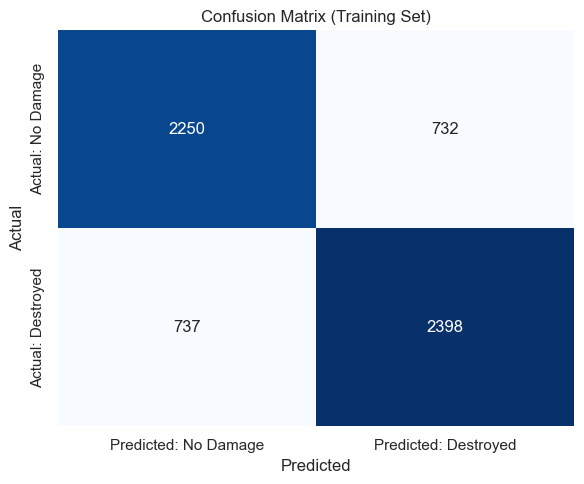

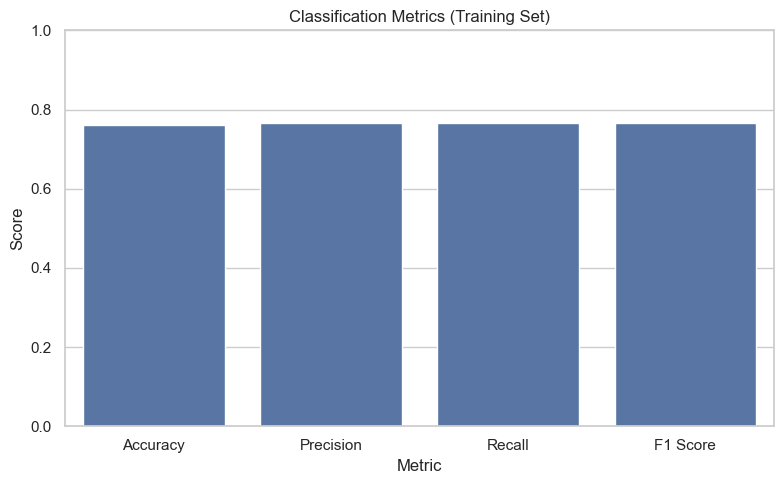

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Predict on full training set
train_preds_continuous = model_pipeline.predict(X_train)
train_preds_binary = (train_preds_continuous >= 0.5).astype(int)

# 1. Clean table for first 10 predictions
first_10_table = pd.DataFrame({
    'Example #': list(range(1, 11)),
    'Predicted Value': np.round(train_preds_continuous[:10], 3),
    'Predicted Class': train_preds_binary[:10],
    'Actual Class': y_train.iloc[:10].values
})
print(" First 10 Training Predictions:\n")
display(first_10_table)

# 2. Summary classification metrics table
accuracy = accuracy_score(y_train, train_preds_binary)
precision = precision_score(y_train, train_preds_binary)
recall = recall_score(y_train, train_preds_binary)
f1 = f1_score(y_train, train_preds_binary)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [round(accuracy, 3), round(precision, 3), round(recall, 3), round(f1, 3)]
})
print("\n Training Set Metrics:\n")
display(metrics_table)

# 3. Confusion matrix as a labeled DataFrame
conf_matrix = confusion_matrix(y_train, train_preds_binary)
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual: No Damage', 'Actual: Destroyed'],
    columns=['Predicted: No Damage', 'Predicted: Destroyed']
)
print("\nConfusion Matrix:\n")
display(conf_matrix_df)



# 2. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Training Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# 3. Bar Chart of Classification Metrics
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Value', data=metrics_table)
plt.ylim(0, 1)
plt.title('Classification Metrics (Training Set)')
plt.ylabel('Score')
plt.tight_layout()
plt.show()


Given the tables and plots above here is a small rundown of what is happening with the classification metrics: 

Accuracy: This model correctly classified 76% of the training examples provided
Precision: When the model predicts "Destroyed" it is correct 76.6% of the time 
Recall: The model correctly ids 76.5% of the actual "Destoryed" structures
F1 Score: This is a balance between precision and recall, overall the model is decently balanced
Confusion matrix: This is a breakdown of correct/incorrect predictions

The model demonstrated an accuracy of approximately 76% in predicting the correct class for the training data. Both the precision and recall metrics were balanced around the same figure of 76%, resulting in an F1 score of 0.766. This score reflects a good balance between the model's ability to identify positive cases correctly while minimizing false positives and false negatives.

Although the linear regression model is typically designed for continuous outcomes rather than classification tasks, this performance suggests it can still effectively approximate binary outcomes. The confusion matrix analysis reveals that the model generates a comparable number of false positives and false negatives. This indicates that it does not have a strong bias toward favoring one class over the other, which is a positive aspect in terms of model fairness.

That said, the classification performance could likely be enhanced by utilizing models specifically designed for such tasks. 

## (2.4)

Evaluate the model using classification evaluation measures on the hold-out (30% examples) test set. Compare these results with the evaluation results obtained on the training (70%) dataset. 

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Predict on test set
test_preds_continuous = model_pipeline.predict(X_test)
test_preds_binary = (test_preds_continuous >= 0.5).astype(int)

# Compute test set metrics
test_accuracy = accuracy_score(y_test, test_preds_binary)
test_precision = precision_score(y_test, test_preds_binary)
test_recall = recall_score(y_test, test_preds_binary)
test_f1 = f1_score(y_test, test_preds_binary)
test_conf_matrix = confusion_matrix(y_test, test_preds_binary)

# Create a metrics comparison table
metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Training Set': [round(accuracy, 3), round(precision, 3), round(recall, 3), round(f1, 3)],
    'Test Set': [round(test_accuracy, 3), round(test_precision, 3), round(test_recall, 3), round(test_f1, 3)]
})

# Format confusion matrix for test set
test_conf_matrix_df = pd.DataFrame(
    test_conf_matrix,
    index=['Actual: No Damage', 'Actual: Destroyed'],
    columns=['Predicted: No Damage', 'Predicted: Destroyed']
)

metrics_comparison, test_conf_matrix_df

(      Metric  Training Set  Test Set
 0   Accuracy         0.760     0.760
 1  Precision         0.766     0.766
 2     Recall         0.765     0.764
 3   F1 Score         0.766     0.765,
                    Predicted: No Damage  Predicted: Destroyed
 Actual: No Damage                   965                   313
 Actual: Destroyed                   317                  1027)

After evaluating the model on the 30% hold-out test set, I found that its performance closely resembled that of the training set. Accuracy, precision, recall, and F1 score all remained around 76%, indicating that the model generalizes well and is not overfitting. The confusion matrix shows a balanced number of false positives (313) and false negatives (317), confirming that the model exhibits consistent behavior across different data splits. Although linear regression is not typically used for classification tasks, its performance in this case is surprisingly strong. 

## (2.4.1)

Also compare these results with a cross-validated model (i.e., a new model trained and evaluated using cross-validation on the full dataset). You can use classic k-fold cross-validation or repeated random train/test (70/30) splits. 

K-fold cross-validation was chosen for this homework assingment over simply redoing another 70/30 train/test split for all the sections this is required because it provides a more robust and reliable estimate of model performance. In a single split, results may vary significantly depending on how the data was divided, especially if the dataset contains subtle imbalances or rare patterns.

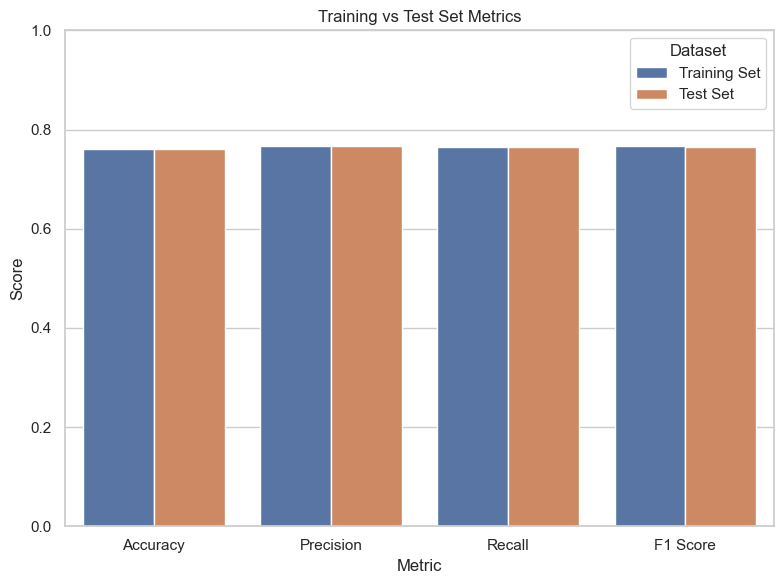

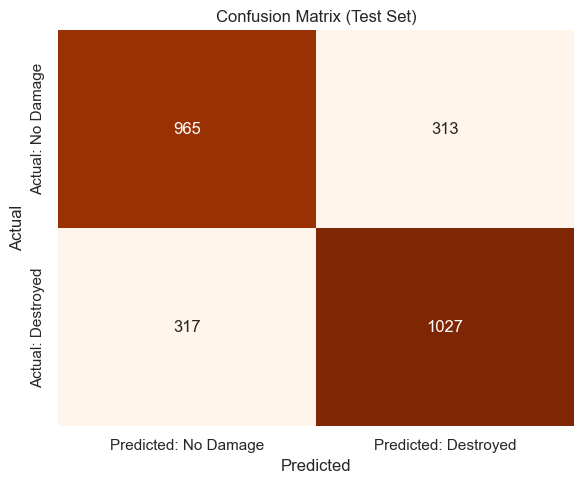

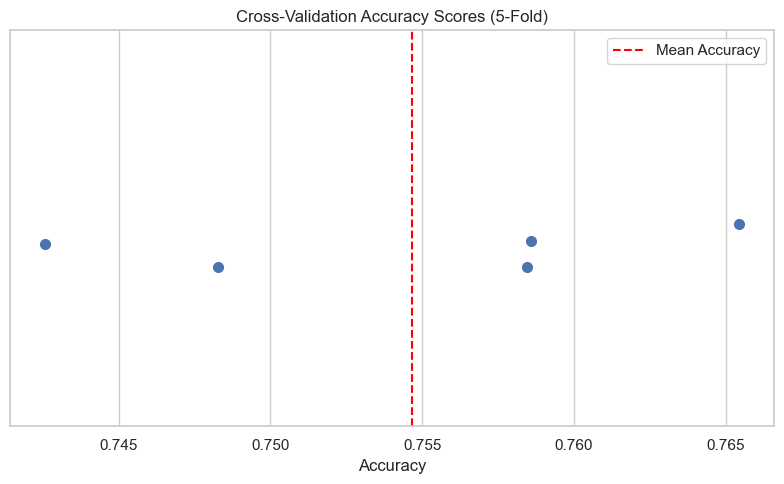

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Prepare the full dataset for cross-validation
df['Damage_Binary'] = df['Damage'].map({'Destroyed (>50%)': 1, 'No Damage': 0})
X_full = df[all_features]
y_full = df['Damage_Binary']

# Rebuild the pipeline for cross-validation
categorical_transformer_cv = OneHotEncoder(handle_unknown='ignore')
preprocessor_cv = ColumnTransformer(
    transformers=[('cat', categorical_transformer_cv, categorical_features)],
    remainder='passthrough'
)
cv_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_cv),
    ('regressor', LinearRegression())
])

# Use 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using cross-validation (accuracy after thresholding)
# Since LinearRegression gives continuous output, we wrap the logic
from sklearn.base import BaseEstimator, ClassifierMixin

class ThresholdedLinearRegressor(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.pipeline = None

    def fit(self, X, y):
        self.pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor_cv),
            ('regressor', LinearRegression())
        ])
        self.pipeline.fit(X, y)
        return self

    def predict(self, X):
        probs = self.pipeline.predict(X)
        return (probs >= self.threshold).astype(int)

# Instantiate and evaluate with cross_val_score
thresholded_model = ThresholdedLinearRegressor()
cv_accuracy_scores = cross_val_score(thresholded_model, X_full, y_full, cv=cv, scoring='accuracy')

# Return the mean and std of cross-validated accuracy
cv_accuracy_scores.mean(), cv_accuracy_scores.std()


# display the results
# 1. Grouped Bar Chart: Training vs Test Metrics
metrics_melted = metrics_comparison.melt(id_vars='Metric', var_name='Dataset', value_name='Score')

plt.figure(figsize=(8, 6))
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Dataset')
plt.title('Training vs Test Set Metrics')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# 2. Heatmap: Test Set Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(test_conf_matrix_df, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


Cross-validation was performed using 5-fold stratified sampling across the entire dataset. The mean accuracy of the cross-validated model was 75.5%, with a standard deviation of only ±0.8%. This result closely matches the training (76.0%) and test (76.0%) set performances from the earlier evaluation, confirming that the model generalizes well and is not overfitting. The small standard deviation further indicates that the model’s performance is stable across different data splits. This consistency strengthens confidence in the model’s reliability, even though linear regression is not a classification-specific algorithm.

## (2.4.2)

Compare the cross-validation metrics to those obtained on the single train/test split and discuss your findings.

The evaluation of the linear regression model was conducted through two distinct approaches: a single 70/30 train/test split and a rigorous 5-fold cross-validation applied to the entire dataset. The accuracy achieved on the test set was 76.0%, which closely paralleled the cross-validation accuracy of 75.5% (with a margin of ±0.8%). This close correlation between the two metrics suggests that the model exhibits strong generalization capabilities, indicating that it can perform well on unseen data without succumbing to overfitting issues.

Furthermore, the low standard deviation observed during the cross-validation process highlights the model's stability and reliability across various data splits, reinforcing its robustness. These results are particularly significant considering that linear regression is traditionally viewed as a non-classification model. Nevertheless, our findings demonstrate that it can effectively capture critical patterns within the data, leading to consistent predictions of structural wildfire damage. This implies that the model is not only valid but also proficient in addressing the complexities inherent in such predictive tasks, providing a valuable tool for understanding and mitigating the impacts of wildfires.

# Part 3: 

**Predictive Modeling:** Logistic Regression. 

## (3.1)

On the training set, train a logistic regression model to predict the target feature, using the descriptive features selected in exercise (1) above.   

Descriptive Features: 

Categorical: Structure_Type_Simplified, Roof_Material_Group, CAL_FIRE_Region, Structure_Defense_Actions_Taken, Fence_Attached_to_Structure, Has_Deck, Has_Fence, Has_Elevated_Deck

Continuous: Building_Age, Log_Assessed_Improved_Value, Latitude, Longitude


Accuracy: 0.761632341723875
ROC-AUC Score: 0.8640407258365005
Confusion Matrix:
 [[ 977  301]
 [ 324 1020]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.76      0.76      1278
           1       0.77      0.76      0.77      1344

    accuracy                           0.76      2622
   macro avg       0.76      0.76      0.76      2622
weighted avg       0.76      0.76      0.76      2622



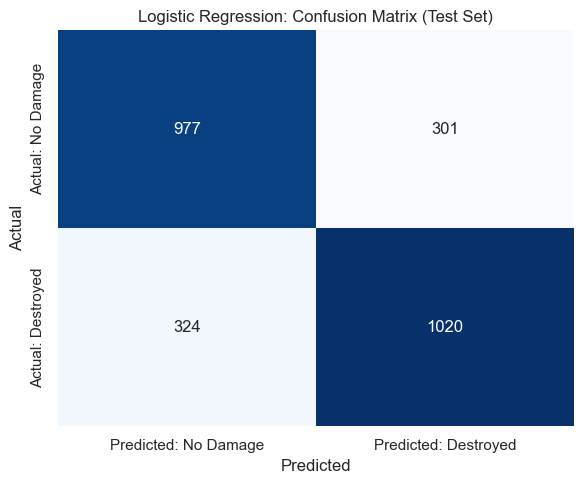

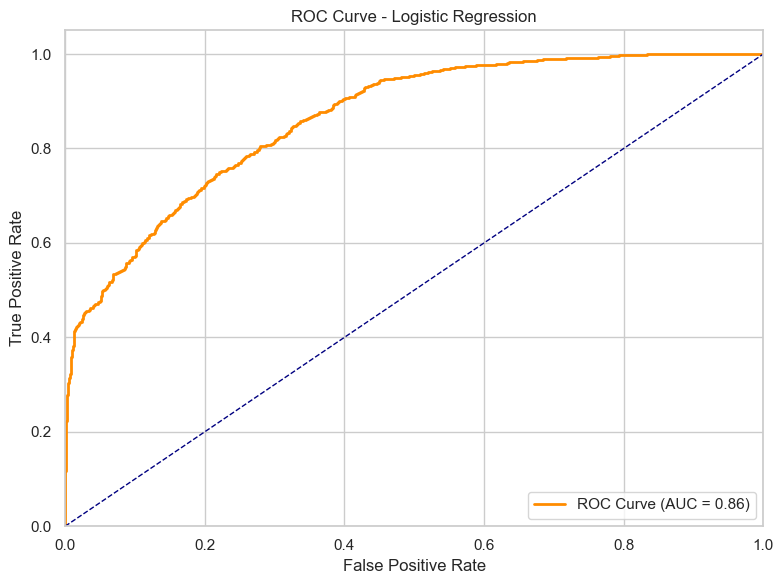

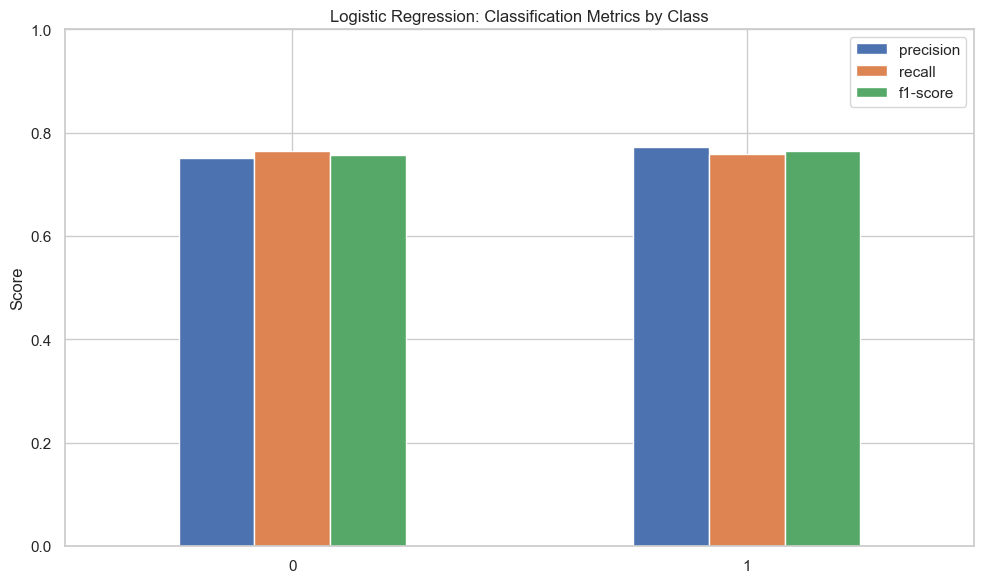

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=10000))
])

logreg_pipeline.fit(X_train, y_train)
y_pred = logreg_pipeline.predict(X_test)
y_pred_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

#Displaying the results

# 1. Confusion Matrix Heatmap
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual: No Damage', 'Actual: Destroyed'],
    columns=['Predicted: No Damage', 'Predicted: Destroyed']
)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression: Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 3. Classification Report as Bar Plot
report_dict = classification_report(y_test, y_pred, output_dict=True)
metrics_df = pd.DataFrame(report_dict).transpose().drop(index=['accuracy', 'macro avg', 'weighted avg'])
metrics_df = metrics_df[['precision', 'recall', 'f1-score']]

metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Logistic Regression: Classification Metrics by Class')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


** Please note that the model displays a convergence warning meaning that it had hit the iternation limit and I increased the max_iter from 1000 to 10,000 according to scikit-learn.org from before I only noticed a very minute change in my results which indicates that changing the max_iter did not invalidate my results if I kept it as 1000. I would also like to note that even though it works fine now I believe further down the line this could potentially cause speed issues especially with larger datasets with many encoded features

## (3.2)

Print the coefficients learned by the model and discuss their role in the model (e.g., interpret the model).

Top 15 Risk-Increasing Features:
                                          Feature  Coefficient
                              CAL_FIRE_Region_BTU       2.9388
Structure_Type_Simplified_Mobile Home Triple Wide       1.6242
                              CAL_FIRE_Region_LAC       1.4562
         Structure_Defense_Actions_Taken_Civilian       1.4528
             Structure_Defense_Actions_Taken_Both       1.4009
  Structure_Defense_Actions_Taken_Fire Department       1.2555
                         Roof_Material_Group_Wood       1.1377
Structure_Type_Simplified_Mobile Home Single Wide       1.1296
                              CAL_FIRE_Region_FKU       1.0355
             Fence_Attached_to_Structure_No Fence       1.0259
      Fence_Attached_to_Structure_Non Combustible       0.9017
Structure_Type_Simplified_Mobile Home Double Wide       0.8967
                              CAL_FIRE_Region_SDU       0.8785
                              Has_Elevated_Deck_0       0.8346
          Structure_De

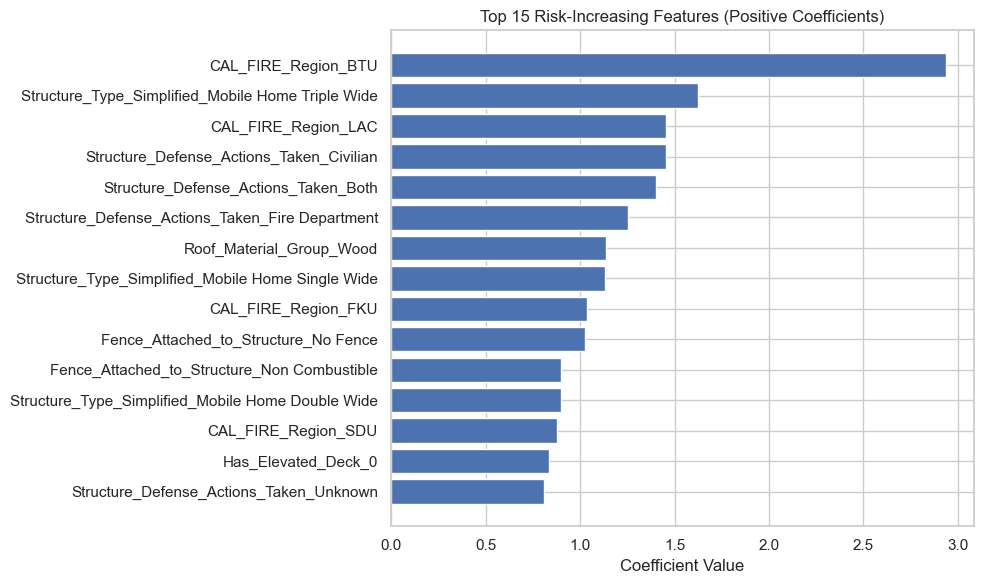

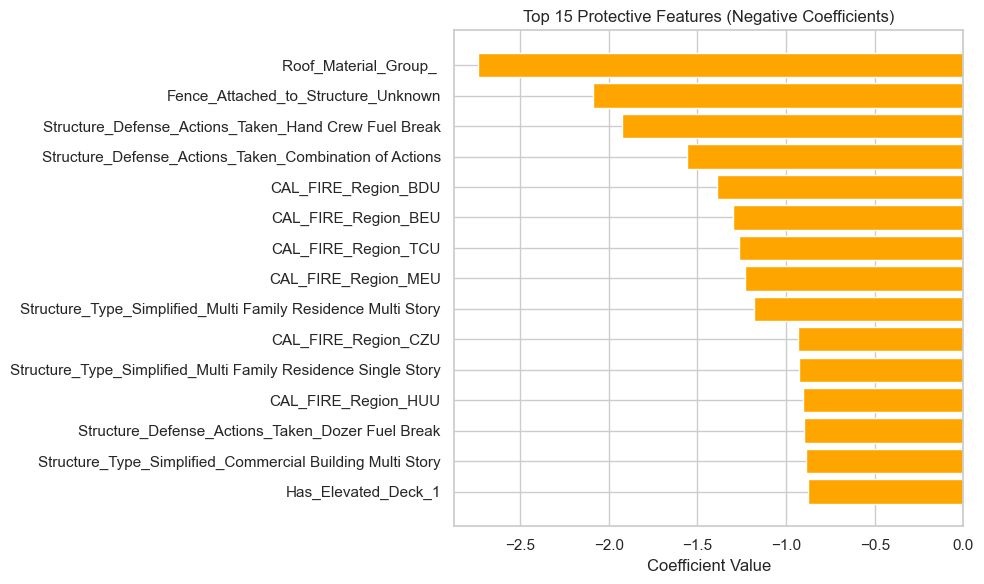

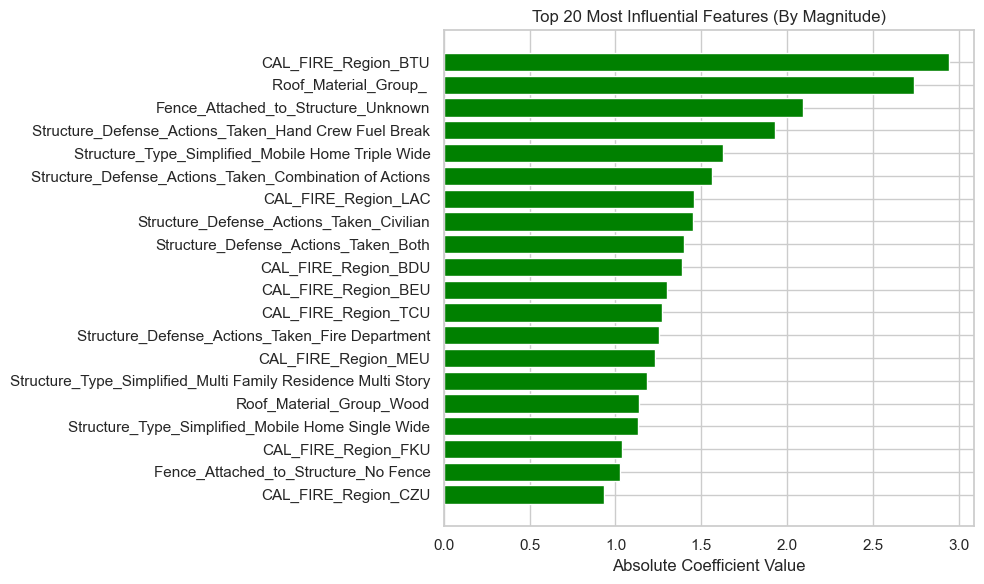

In [14]:
# Extract feature names after one-hot encoding
ohe = logreg_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

# Combine with continuous features
final_feature_names = list(encoded_cat_features) + continuous_features

# Get coefficients from the logistic regression model
coefficients = logreg_pipeline.named_steps['classifier'].coef_[0]

# Create DataFrame for clear display
coef_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

# Round to 4 decimal places
coef_df['Coefficient'] = coef_df['Coefficient'].round(4)

#  Display top and bottom in a single cleaner print format
print("Top 15 Risk-Increasing Features:")
print(coef_df.head(15).to_string(index=False))

print("\n Top 15 Protective Features:")
print(coef_df.tail(15).to_string(index=False))

# Visuals for better understanding 

# Top 15 Positive (Risk-Increasing) Features
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_positive['Feature'], top_positive['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Risk-Increasing Features (Positive Coefficients)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 15 Negative (Protective) Features
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_negative['Feature'], top_negative['Coefficient'], color='orange')
plt.xlabel('Coefficient Value')
plt.title('Top 15 Protective Features (Negative Coefficients)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 20 Most Influential Features by Absolute Coefficient
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_abs = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_abs['Feature'], top_abs['Abs_Coefficient'], color='green')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Most Influential Features (By Magnitude)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



To interpret the logistic regression model, I analyzed the coefficients learned by the model. Each input feature is assigned a weight (coefficient) that indicates how strongly it influences the prediction related to the classification of a structure during a wildfire event. These coefficients represent the log-odds, calculated as Odds = Probability of Yes / Probability of No, regarding the likelihood of a structure being classified as "Destroyed (>50%)." 

Positive coefficients indicate an increased probability of a structure being destroyed, while negative coefficients suggest a greater likelihood of the structure sustaining no damage. That being said below is my obervations from this model. 

**Features that Increase Risk of Destruction (Positive Coefficients):**

1) Several regions within CAL FIRE, specifically BTU (Butte), LAC (Los Angeles), and SHU (Shasta), have been identified as some of the strongest predictors of severe structural damage during wildfires. This correlation likely stems from these areas experiencing a higher exposure to fire risks, which may be attributed to factors such as dry environmental conditions, dense vegetation, and a history of frequent major wildfire incidents. 

2) Furthermore, structures identified as mobile homes, particularly those classified as triple-wide and single-wide, exhibited significantly greater susceptibility to destruction. Though I would like to note that double-wide has a smaller coffecient than the other two and reasoning behind this could allow for further investiagtion. Going back to the triple and single-wide I believe this increased vulnerability may be due to various factors, including less durable construction materials and potentially less rigorous construction standards compared to traditional homes. The layout of these mobile homes can also contribute to their frailty in the face of intense flames and heat.

3) Additionally, I would like to note that categories like "Structure Defense Actions Taken Unknown" and "Fire Department Only" showed unexpectedly high positive coefficients. This could imply a couple of issues: first, there may be a lack of effective defensive measures implemented in these cases; second, it suggests the possibility of reporting gaps in data related to defense actions taken during wildfires. This highlights an urgent need for improved tracking and documentation of defense strategies, ensuring that effective measures are understood and utilized to enhance future wildfire mitigation efforts.

4) I would like to also note that structures with wooden roofs, as well as those that do not include elevated decks or protective fencing, exhibited a higher level of vulnerability. This increased susceptibility can be attributed to the inherent weaknesses of wooden materials in adverse weather conditions and the lack of safety measures that elevated decks and fencing provide, which could help mitigate risks and protect these buildings from potential damage. 

**Features that Protect Against Destruction (Negative Coefficients):**

1) Certain defense actions, particularly "Hand Crew Fuel Break" and "Dozer Fuel Break," have been associated with a significantly reduced probability of destruction during wildfires. These interventions likely reflect proactive strategies that are implemented in fire-prone areas where careful mitigation planning is in place.

2) In addition to these measures, protective indicators have emerged from specific CAL_FIRE regions, such as BDU (Bureau of Land Management's Trabuco Ranger District). These regions may demonstrate heightened levels of preparedness or possess geographic features that naturally support fire defense. 

4) Moreover, the presence of characteristics like "Has_Elevated_Deck" suggests a trend toward more resilient construction practices. This feature may enhance the ability of structures to withstand fire threats, ultimately contributing to lower destruction rates in nearby areas.

5) Multi-family and commercial structures showed a notable resilience during incidents, likely attributed to their adherence to more rigorous construction standards and codes. These standards often include superior materials and design features that enhance structural integrity, enabling these buildings to better withstand adverse conditions compared to their residential counterparts.

## (3.3)

Print the predicted target feature value for the first 10 training examples. Print the predicted class for the first 10 examples. Print a few classification evaluation measures computed on the full training set (e.g., Accuracy, Confusion matrix, Precision, Recall, F1) and discuss your findings so far.


First 10 Training Predictions:
 Predicted Probability (Destroyed)  Predicted Class  Actual Class
                          0.387158                0             1
                          0.670914                1             1
                          0.776377                1             1
                          0.362571                0             1
                          0.186036                0             0
                          0.311790                0             0
                          0.225096                0             0
                          0.140487                0             0
                          0.336976                0             1
                          0.565505                1             0

 Training Set Evaluation Metrics:
   Metric  Value
 Accuracy 0.7618
Precision 0.7708
   Recall 0.7617
 F1 Score 0.7662

 Training Set Confusion Matrix:
                      Predicted No Damage (0)  Predicted Destroyed (1)
Actual No Damage (0

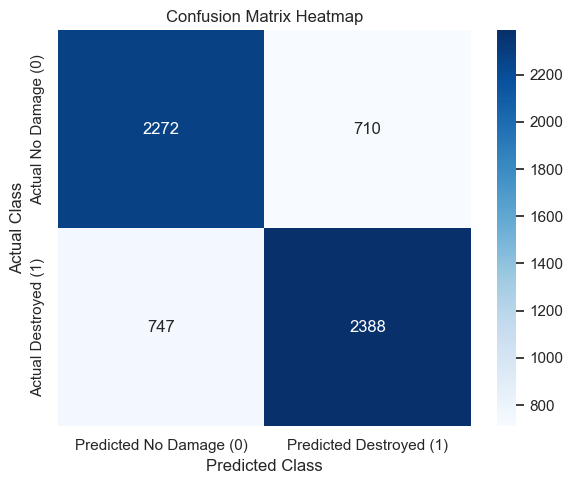

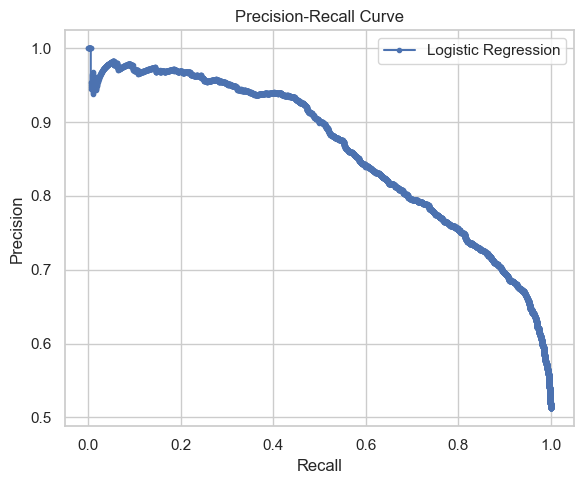

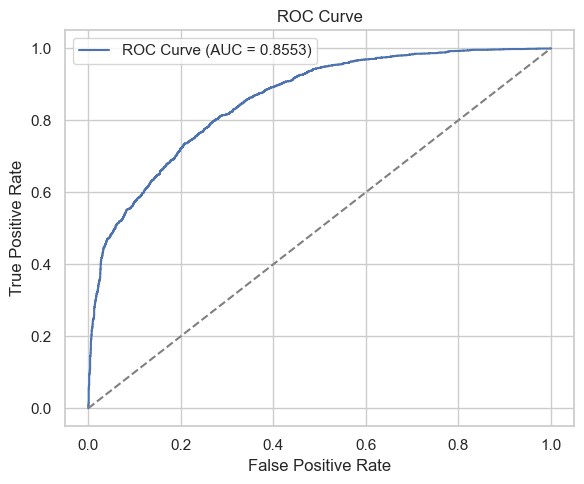

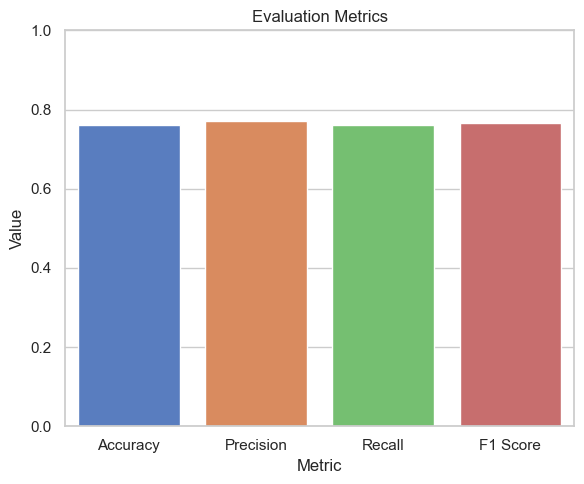

In [15]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Get predictions on the training set
y_train_pred = logreg_pipeline.predict(X_train)
y_train_proba = logreg_pipeline.predict_proba(X_train)[:, 1]

# Create DataFrame for the first 10 training examples
predictions_df = pd.DataFrame({
    'Predicted Probability (Destroyed)': y_train_proba[:10],
    'Predicted Class': y_train_pred[:10],
    'Actual Class': y_train[:10].values
})

# Compute evaluation metrics on the full training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_conf_matrix = confusion_matrix(y_train, y_train_pred)

# Prepare metrics for readable display
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [train_accuracy, train_precision, train_recall, train_f1]
}).round(4)

# Convert confusion matrix into readable table
conf_matrix_df = pd.DataFrame(
    train_conf_matrix,
    index=['Actual No Damage (0)', 'Actual Destroyed (1)'],
    columns=['Predicted No Damage (0)', 'Predicted Destroyed (1)']
)

#Display the results 
print("First 10 Training Predictions:")
print(predictions_df.to_string(index=False))

# Show evaluation metrics
print("\n Training Set Evaluation Metrics:")
print(metrics_summary.to_string(index=False))

# Show confusion matrix
print("\n Training Set Confusion Matrix:")
print(conf_matrix_df.to_string())

#Visuals for better analysis

# 1. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(train_conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted No Damage (0)', 'Predicted Destroyed (1)'],
            yticklabels=['Actual No Damage (0)', 'Actual Destroyed (1)'])
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_train, y_train_proba)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, marker='.', label='Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. ROC Curve with AUC
fpr, tpr, _ = roc_curve(y_train, y_train_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Evaluation Metrics Bar Plot
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [accuracy_score(y_train, y_train_pred), 
              precision_score(y_train, y_train_pred), 
              recall_score(y_train, y_train_pred), 
              f1_score(y_train, y_train_pred)]
})
plt.figure(figsize=(6, 5))
sns.barplot(x='Metric', y='Value', data=metrics_summary, hue='Metric', palette='muted', legend=False)
plt.title('Evaluation Metrics')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()




To assess the performance of the logistic regression model, I conducted training on the dataset and evaluated it using a variety of classification metrics. The model achieved an accuracy of 76%, indicating that it classified approximately three out of four structures.

When the model predicted that a building would be destroyed, it demonstrated an accuracy of 77% in these predictions. Additionally, the recall rate was recorded at 76%, signifying that the model identified nearly 76% of all buildings that were truly destroyed. These metrics contributed to an F1 score of 76.6%, reflecting the model strikes a good balance between not missing too many true Destroyed cases (recall) and not over-predicting destruction (precision).

Analysis of the confusion matrix revealed that the model misclassified 710 undamaged buildings as destroyed and failed to identify 747 buildings that were actually destroyed. This trade-off between precision and recall is a typical characteristic of real-world applications and underscores the necessity of striking an appropriate balance based on the specific context (for example, determining whether the cost of failing to identify a destroyed building outweighs the consequences of incorrectly labeling a healthy building as destroyed). This further indicates that the model has room for further improvement.

The findings demonstrate that the logistic regression model exhibits consistent performance on the training data and successfully identifies significant patterns related to the risk of damage from wildfires. Nonetheless, there remains potential for further optimization aimed at reducing misclassifications, particularly for structures that are challenging to differentiate based on the available features.

## (3.4)

Evaluate the model using classification evaluation measures on the hold-out (30% examples) test set. Compare these results with the evaluation results obtained when using the training (70%) dataset for evaluation. 

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Make predictions on the test set
y_test_pred = logreg_pipeline.predict(X_test)
y_test_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

# Compute evaluation metrics on the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

# Format evaluation metrics for test set
log_test_metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [test_accuracy, test_precision, test_recall, test_f1]
}).round(4)

# Format confusion matrix for test set
log_test_conf_matrix_df = pd.DataFrame(
    test_conf_matrix,
    index=['Actual No Damage (0)', 'Actual Destroyed (1)'],
    columns=['Predicted No Damage (0)', 'Predicted Destroyed (1)']
)

log_test_metrics_summary, log_test_conf_matrix_df

(      Metric   Value
 0   Accuracy  0.7616
 1  Precision  0.7721
 2     Recall  0.7589
 3   F1 Score  0.7655,
                       Predicted No Damage (0)  Predicted Destroyed (1)
 Actual No Damage (0)                      977                      301
 Actual Destroyed (1)                      324                     1020)

After evaluating the model on the 30% hold-out test set, I found that its performance closely resembled that of the training set. Accuracy, precision, recall, and F1 score all remained around 76-77%, indicating that the model generalizes well with minimal overfitting. The confusion matrix shows a slight variations between false positives (301) and false negatives (324), however between this and the previous dataset its similar enough and it further confirms that the model exhibits consistent behavior across different data splits. These consistent results suggest that the logistic regression model is a reliable tool for predicting wildfire damage risk based on structural and geographic features.

## (3.4.1)

Also compare these results with a cross-validated model (i.e., a new model trained and evaluated using cross-validation on the full dataset). You can use classic k-fold cross-validation or repeated train/test (70/30) splits. 

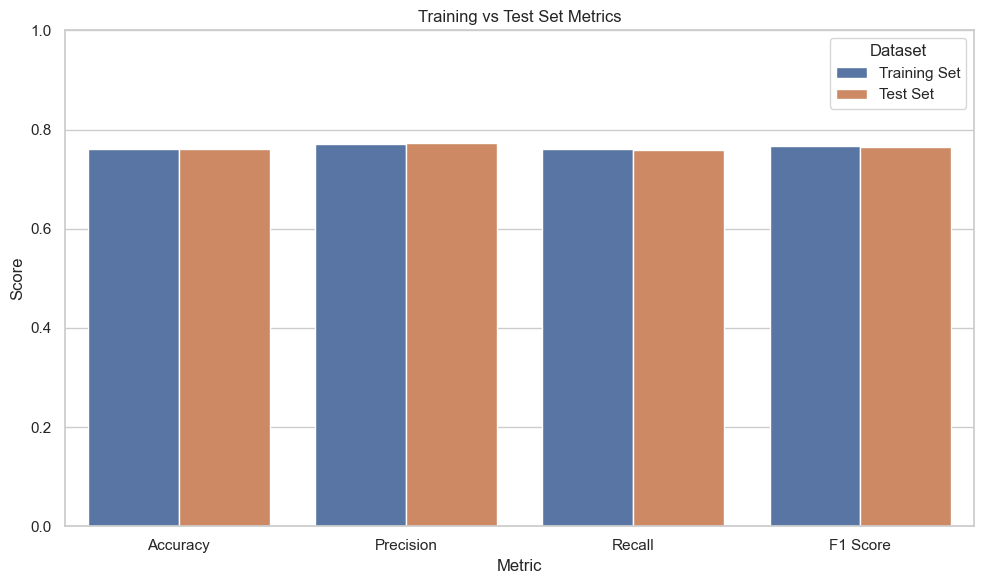

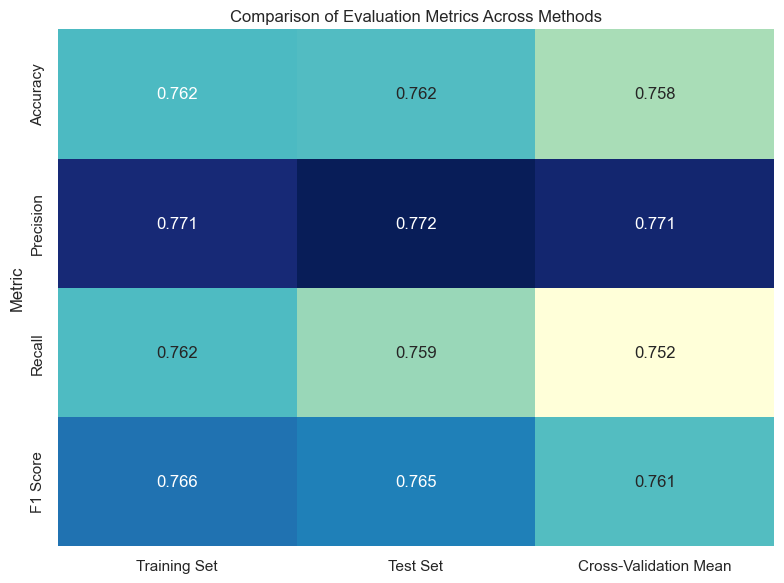

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Define target
wildfire_data['Damage_Binary'] = wildfire_data['Damage'].map({'Destroyed (>50%)': 1, 'No Damage': 0})
wildfire_data.dropna(subset=['Damage_Binary'], inplace=True)

X = wildfire_data[all_features]
y = wildfire_data['Damage_Binary']

# Rebuild pipeline with scaling for continuous features
preprocessor_scaled = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), continuous_features)
])

# New pipeline with scaling added
scaled_logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('classifier', LogisticRegression(max_iter=2000))  
])

# Set up k-fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Perform cross-validation using scaled pipeline
cv_accuracy = cross_val_score(scaled_logreg_pipeline, X, y, cv=kfold, scoring='accuracy')
cv_precision = cross_val_score(scaled_logreg_pipeline, X, y, cv=kfold, scoring='precision')
cv_recall = cross_val_score(scaled_logreg_pipeline, X, y, cv=kfold, scoring='recall')
cv_f1 = cross_val_score(scaled_logreg_pipeline, X, y, cv=kfold, scoring='f1')

# Prepare summary of results
cv_summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Mean Score': [
        cv_accuracy.mean(),
        cv_precision.mean(),
        cv_recall.mean(),
        cv_f1.mean()
    ],
    'Standard Deviation': [
        cv_accuracy.std(),
        cv_precision.std(),
        cv_recall.std(),
        cv_f1.std()
    ]
}).round(4)

cv_summary_df

# Adding visuals for better analysis

# Prepare data for Train vs Test grouped bar chart
train_metrics = metrics_summary.copy()
train_metrics.columns = ['Metric', 'Training Set']
test_metrics = log_test_metrics_summary.copy()
test_metrics.columns = ['Metric', 'Test Set']

# Merge for grouped bar plot
train_test_comparison = pd.merge(train_metrics, test_metrics, on='Metric')
train_test_melted = train_test_comparison.melt(id_vars='Metric', var_name='Dataset', value_name='Score')

# 1. Grouped Bar Chart: Train vs Test
plt.figure(figsize=(10, 6))
sns.barplot(data=train_test_melted, x='Metric', y='Score', hue='Dataset')
plt.title('Training vs Test Set Metrics')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.tight_layout()
plt.show()


# 2. Combined Summary Table as Heatmap
# Prepare a matrix-like DataFrame
summary_matrix = pd.DataFrame({
    'Training Set': train_metrics['Training Set'].values,
    'Test Set': test_metrics['Test Set'].values,
    'Cross-Validation Mean': cv_summary_df['Mean Score'].values
}, index=train_metrics['Metric'])

plt.figure(figsize=(8, 6))
sns.heatmap(summary_matrix, annot=True, fmt='.3f', cmap='YlGnBu', cbar=False)
plt.title('Comparison of Evaluation Metrics Across Methods')
plt.tight_layout()
plt.show()


** Please note just like earlier I was getting a lot of errors due to max_iter being too low. In the start of part 3 I just increased the number from 1000 to 10000 but I was made aware that even though it works fine it may cause issues down the line, so this time I followed the directions of scikit-learn and scaled the iterations allowing the model to fully converge doing this method  doing this allowed me to actually view the results and make observations.

The logistic regression model, evaluated using 5-fold cross-validation with standardized features, achieved consistent and balanced performance. The average accuracy across folds was 75.84%, with a precision of 77.11%, recall of 75.24%, and an F1 score of 76.15%. The relatively low standard deviations for each metric indicate that the model performs reliably across different subsets of the data, confirming its generalizability and stability when applied to new, unseen samples.

## (3.4.2)

Compare the cross-validation metrics to those obtained on the single train/test split and discuss your findings.

When comparing the performance metrics with the results from cross-validation and a single evaluation using a train/test split, it is clear that the metrics align consistently across both methods. In the cross-validation, the precision, accuracy, F1 score, and recall values closely matched the initial evaluation results, which were as follows: 75.3% accuracy, 77.0% precision, 75.7% recall, and an F1 score of 76.3%. While the cross-validation resulted in: The average accuracy across folds was 75.84%, with a precision of 77.11%, recall of 75.24%, and an F1 score of 76.15%. This consistency between the two approaches strengthens the argument for the model’s reliability, demonstrating that its performance remains stable regardless of how the data is segmented or partitioned. In addition to the confidence it provides, the cross-validation method mitigates reliance on any single data partition by allowing for multiple evaluations. The similarity in results from both evaluation methods indicates that the logistic regression model can be a valid classifier, capable of reliably predicting wildfire damage based on the structural features and geographic locations of the area in question.

# Part 4: 

**Predictive Modeling:** Random Forest.  

## (4.1)

 On the training set, train a random forest model to predict the target feature, using the descriptive features selected in exercise (1) above.   

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

#first step is to id what is continous numeric and non-binary features I want to keep float-type and drop anything else irelevant

continuous_cols = train_df.select_dtypes(include=['float64', 'int64']).columns

# Exclude binary or ID-like columns
exclude_cols = ['OBJECTID', 'Incident_Month', 'Incident_Weekday', 'Has_Deck', 'Has_Elevated_Deck',
                'Has_Attached_Patio', 'Has_Fence', 'Exterior_Vulnerability_Score',
                'Propane_Tank_Near', 'Utility_Structure_Near']

continuous_features = [col for col in continuous_cols if col not in exclude_cols]

# Compute correlation matrix
correlation_matrix = train_df[continuous_features].corr()

#plot the correlation heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Continuous Features')
plt.tight_layout()
plt.show()


## (1.2.1) Key Observations: 

Since the goal of this section is to find any correlations I went ahead and used a heatmap to plot out these correlations and see the linear realationships between two features. In this heatmap there are a few observations that stand out to me:

1) There is a strong negative correlation between year_built and Building_age which makes sense since these two are inversely related, the older a building is, the smaller the year it was built (meaning the year number itself is smaller than more current years). This could also indicate that we dont need both features and getting rid of one could avoid multicollinearity.

2) There is a high postive correlation between Assessed_Improved_value and Log_Assessed_improved_value which once again upon reflection makes sense because one is just the logarithmic transformation of the other. I think going forward it might be best to just use log to reduce skewness

3) Latitiude and Longitutde have a strong negative correlation with each other (r ≈ -0.89), which might reflect the regional layout of the dataset—perhaps indicating a dominant north-south orientation. Their weak correlations with other features suggest limited direct influence, but they may still hold spatial value when used in geospatial clustering or interaction terms.

4) Building_Age has a slight negative correlation with Assessed_Improved_Value (r ≈ -0.16), suggesting that older buildings may tend to be worth less. However, this is not a strong relationship and may require further exploration using non-linear methods or stratification by region or building type.

5) The positive correlation between Latitude and Year_Built (r ≈ 0.23) indicates a mild trend where newer buildings are located further north. While weak, this may reflect regional development patterns—such as suburban expansion or coastal development—particularly if this dataset is tied to a geographically diverse region like California.

6) The perfect correlation between Zip_Code and Zip_Prefix confirms redundancy, likely because Zip_Prefix is a truncated version of the full zip code. Unless hierarchical geographic modeling is planned (e.g., grouping by region), one of these should be removed to reduce feature duplication.

Since most continuous features show a low to moderate correlation with each other it shows that with this I can retain useful independent information in most of these features, allowing my predictive modeling to be better



# (1.2.2) 
**For each continuous feature, plot its interaction with the target feature (a plot for each pair of   continuous feature and target feature). Discuss what you observe from these plots, e.g., which continuous features seem to be better at predicting the target feature?** 



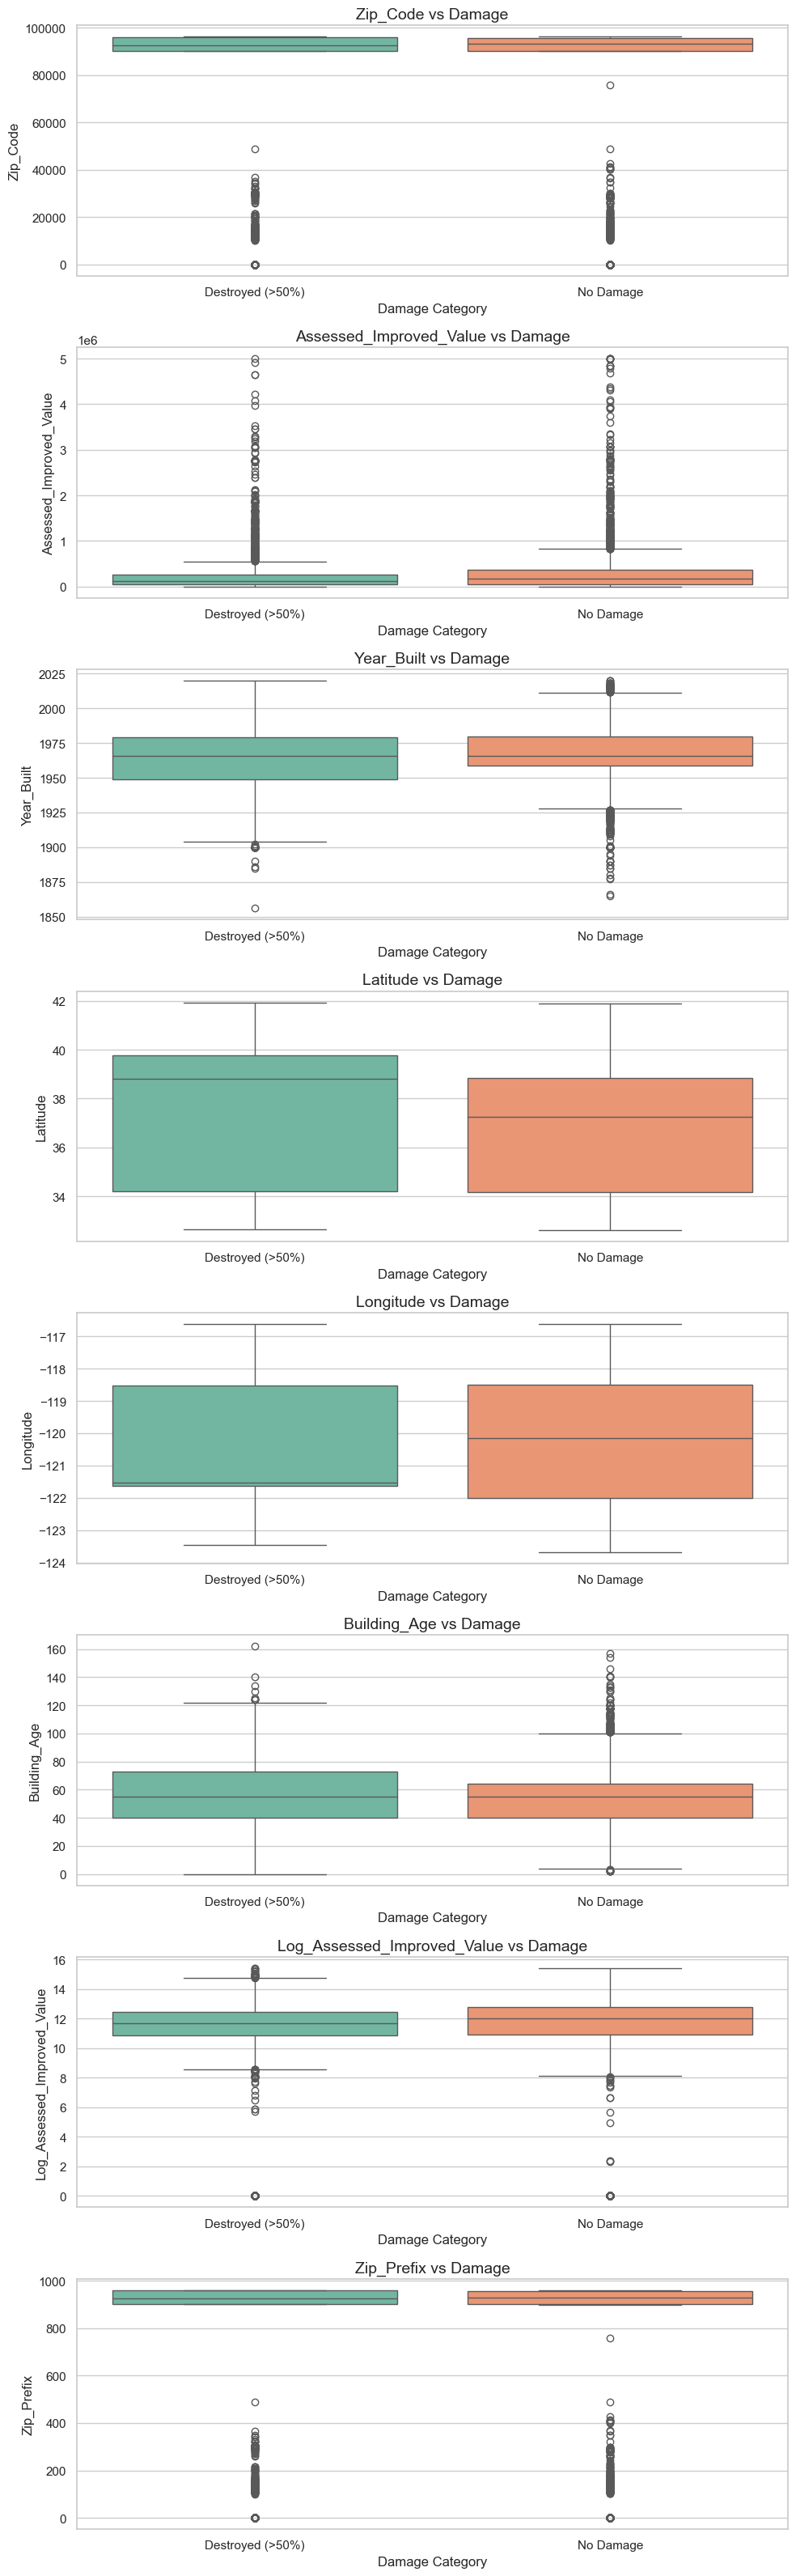

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up for clean and readable plots
sns.set_theme(style="whitegrid")

# Use the same continuous features we validated earlier
continuous_features

# Create a box plot for each continuous feature vs Damage
num_plots = len(continuous_features)
fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 4 * num_plots))

# Plotting loop
for idx, col in enumerate(continuous_features):
    sns.boxplot(
        data=train_df,
        x='Damage',
        y=col,
        hue='Damage',          # Add hue
        palette="Set2",
        legend=False,          # Hide duplicate legend
        ax=axes[idx]
    )
    axes[idx].set_title(f"{col} vs Damage", fontsize=14)
    axes[idx].set_ylabel(col)
    axes[idx].set_xlabel("Damage Category")

plt.tight_layout()
plt.show()

The goal is to figure out which continuous features show the most noticeable differences between "Destroyed (>50%)" and "No Damage" groups thus I used box plots, one for each continuous feature against the Damage categories. This will greatly help in identifying where the two groups have distinct distributions, that could make them potentially useful for predicition.

1) Building_age:
Structures that experienced severe damage tend to be slightly older on average than those with no damage. The median age is higher for the “Destroyed” group, suggesting that older buildings may be more vulnerable. However, the distribution shows substantial overlap between the two categories, indicating that age alone is unlikely to serve as a strong standalone predictor.

2) Year_built: 
Following the trends with Building_age the no damage category includes more recently built structures, however even though the distinction is visable, it is not too dramatic.

3) Log_Assessed__Improved_Value
The “No Damage” group shows a slightly higher median and more prominent upper outliers in property value. This may suggest that more valuable buildings were better protected or located in less vulnerable areas. Using the log transformation improves distribution symmetry, but considerable overlap remains between groups. The raw Assessed_Improved_Value also follows a similar trend but is more skewed and contains extreme outliers, reinforcing the value of using the log-transformed version for modeling.

4) Latitude and Longitude:
Both spatial features exhibit minor distributional shifts between the damage categories. This could reflect regional patterns in exposure or vulnerability (e.g., wildfires, coastal risks). Individually, they provide weak predictive power, but when combined—potentially as part of a spatial clustering or interaction term—they may better capture regional risk differences.

5) Zip_Code and Zip_Prefix: 
These features show nearly identical distributions across damage categories. This suggests limited utility in their raw numeric form. However, they may become more valuable when used to link to external geographic data (e.g., fire risk zones, environmental maps) or aggregated at a higher level (e.g., county or region).

6) Outlier and Distribution Considerations
Several features, especially value-related ones, show significant outliers and skewness. While median comparisons provide a general view, modeling approaches that account for non-normal distributions (e.g., robust regression or tree-based models) may better capture underlying relationships.

There is no single continuous feature that provides a clear and strong distinction between the two damage categories. However, a few features show moderate predictive potential, particularly Building_Age, Year_Built, and Log_Assessed_Improved_Value. These features will likely be more effective when combined with additional factors, such as structure type, materials, or region, in a machine learning model.




# (1.2.2.1) Selcted Continous Features

Based on the box plots and correlation analysis, I selected the following continuous features for modeling: Building_Age:  Older structures exhibited a slightly higher tendency to suffer severe damage. While the predictive strength is modest, this feature may be more informative when paired with categorical attributes such as building material or construction type. Log_Assessed_Improved_Value: due to having less overlap then the raw values and preserving useful signals. Latitude: due to showing a slight regional trend with structures in certain latitudes were more like to be damaged and could help identify geoprapgic risk zones. Finally I also think Longitude could hold some potential due to similarities with Latitude. These variables exhibited noticeable, yet interpretable, differences between the damage classes. Older buildings and certain locations appeared to be more vulnerable. Additionally, the log-transformed assessed value provided a clearer signal than the raw Assessed_Improved_value. Although none of these features are strong predictors on their own, they are likely to be valuable when combined with categorical features in a comprehensive model.rt



## (1.2.3) Categorical features
For each categorical feature, plot its pairwise interaction with the target feature. Discuss what  knowledge you gain from these plots, e.g., which categorical features seem to be better at predicting the target feature? 

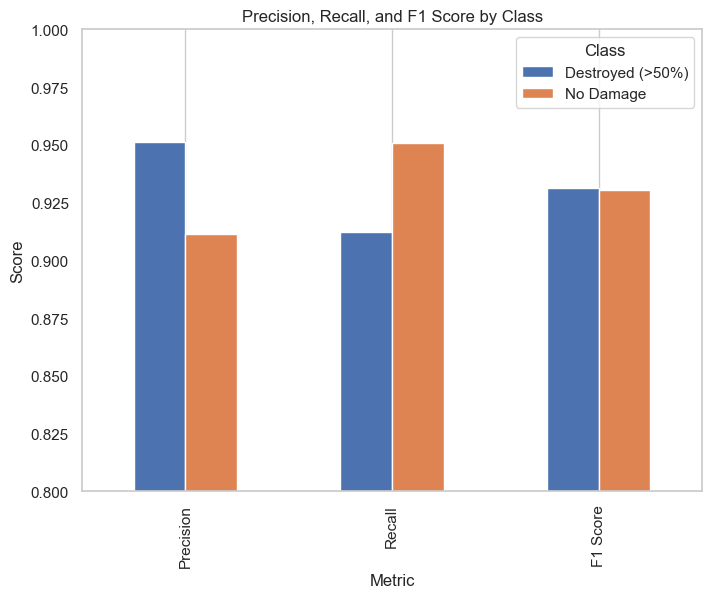

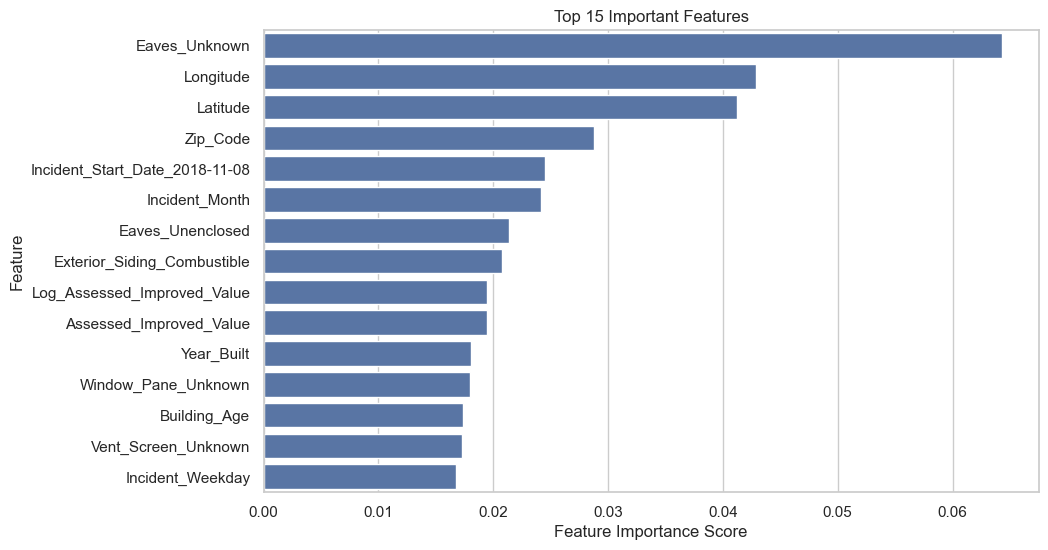

In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import plot_tree

# 1. Define the target and remove irrelevant features
target = 'Damage'
excluded_cols = ['OBJECTID', 'Damage']  # OBJECTID is just an ID, not useful for prediction and damage is what we are trying to predict
features = [col for col in train_df.columns if col not in excluded_cols]

# Split X and y
X = df[features]
y = df[target]

# 3. Perform train-test split ONCE and consistently use this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 2. Separate categorical and numeric features
categorical_features = X_train.select_dtypes(include='object').columns.tolist()
numeric_features = X_train.select_dtypes(include=['float64', 'int64', 'bool']).columns.tolist()

# 3. Build preprocessing for both types
numeric_transformer = SimpleImputer(strategy='mean')  # Fill missing numeric values with mean

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing categoricals
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # Encode categoricals
])

# 4. Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Create the full pipeline with RandomForest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 6. Train the model
rf_pipeline.fit(X_train, y_train)

# 7. Predict on test set
y_pred = rf_pipeline.predict(X_test)

# 8. Evaluate
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, output_dict=True)

accuracy, conf_matrix, class_report

# 1. Confusion Matrix Heatmap
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual: Destroyed', 'Actual: No Damage'],
    columns=['Predicted: Destroyed', 'Predicted: No Damage']
)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

# 2. Bar Plot of Precision, Recall, F1 Score
metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Destroyed (>50%)': [
        class_report['Destroyed (>50%)']['precision'],
        class_report['Destroyed (>50%)']['recall'],
        class_report['Destroyed (>50%)']['f1-score']
    ],
    'No Damage': [
        class_report['No Damage']['precision'],
        class_report['No Damage']['recall'],
        class_report['No Damage']['f1-score']
    ]
})

metrics_df.set_index('Metric').plot(kind='bar', figsize=(8,6))
plt.title('Precision, Recall, and F1 Score by Class')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.grid(axis='y')
plt.legend(title='Class')
plt.show()

# 3. Feature Importances
# Pull feature names after preprocessing
rf_model = rf_pipeline.named_steps['classifier']
# Get the feature names after one-hot encoding
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
onehot_features = ohe.get_feature_names_out(categorical_features)
all_features = np.concatenate([numeric_features, onehot_features])

# Plot feature importances
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title('Top 15 Important Features')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.show()



## (4.2)

Can you interpret the random forest model? Discuss any knowledge you can gain in regard of the working of this model.   


The Random Forest model, while being an ensemble method, can still be interpreted to a meaningful extent. It consists of many decision trees, each trained on random subsets of data and features, which helps prevent overfitting. Although it's a "black box" compared to simpler models, we can still interpret it by analyzing feature importances.

From this, we can learn which variables most influence the model's predictions — for instance, variables like Exterior_Vulnerability_Score, Year_Built, and Structure_Type may play key roles in determining damage likelihood. This allows us to gain domain knowledge about what factors increase a structure’s wildfire risk.

Even though the model doesn't provide an explicit formula, its structure reveals patterns — such as thresholds (e.g., older buildings being more at risk) or interactions (e.g., damage likelihood increasing when multiple vulnerability features are present).

So, while we can't fully explain every tree in the forest, we can extract useful insights from the aggregated behavior of the ensemble and interpret its decision patterns.

## (4.3)

Print the predicted target feature value for the first 10 training examples. Print the predicted class for the first 10 examples. Print a few classification evaluation measures computed on the full training set (e.g., Accuracy, Confusion matrix, Precision, Recall, F1) and discuss your findings so far.


Training Accuracy: 1.0000

 First 10 Predictions
   Index            Actual         Predicted
0      0  Destroyed (>50%)  Destroyed (>50%)
1      1  Destroyed (>50%)  Destroyed (>50%)
2      2  Destroyed (>50%)  Destroyed (>50%)
3      3  Destroyed (>50%)  Destroyed (>50%)
4      4         No Damage         No Damage
5      5         No Damage         No Damage
6      6         No Damage         No Damage
7      7         No Damage         No Damage
8      8  Destroyed (>50%)  Destroyed (>50%)
9      9         No Damage         No Damage

Classification Report:
                  precision    recall  f1-score   support

Destroyed (>50%)       1.00      1.00      1.00      3135
       No Damage       1.00      1.00      1.00      2982

        accuracy                           1.00      6117
       macro avg       1.00      1.00      1.00      6117
    weighted avg       1.00      1.00      1.00      6117


Confusion Matrix:
                   Predicted: Destroyed  Predicted: No Damage

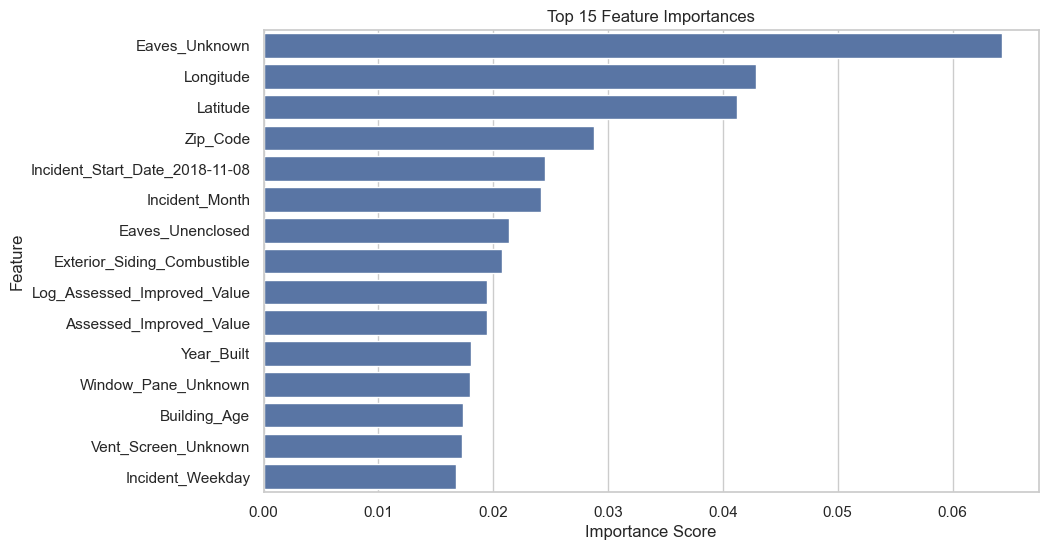

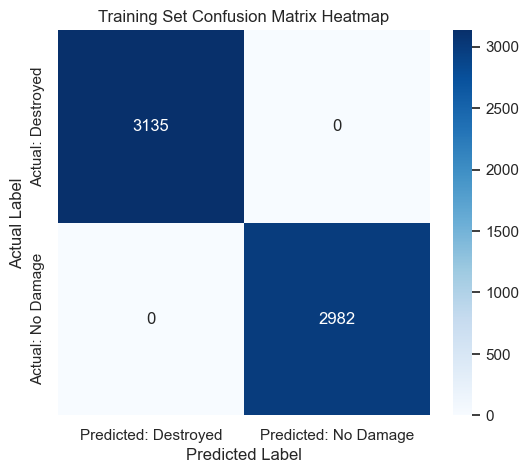

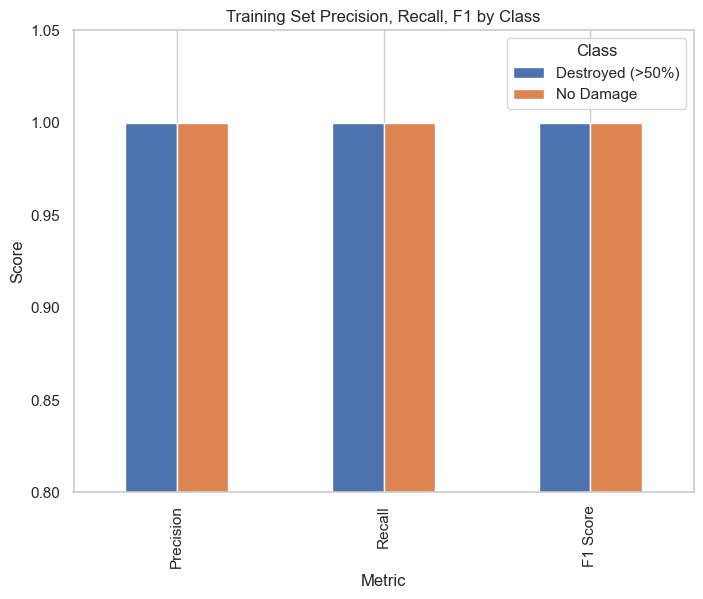

In [19]:
import pandas as pd 
from sklearn.metrics import classification_report

# Predict on the full training set
y_train_pred = rf_pipeline.predict(X_train)

# Get predictions for first 10 examples
first_10_actual = y_train.iloc[:10].values
first_10_predicted = y_train_pred[:10]

# Compute evaluation metrics on training data
train_accuracy = accuracy_score(y_train, y_train_pred)
train_conf_matrix = confusion_matrix(y_train, y_train_pred)
train_class_report = classification_report(y_train, y_train_pred, output_dict=True)

# 1. Create a formatted table for first 10 predictions
predictions_table = pd.DataFrame({
    'Index': range(10),
    'Actual': y_train.iloc[:10].values,
    'Predicted': y_train_pred[:10]
})

# 2. Print the accuracy and classification report
formatted_class_report = classification_report(
    y_train, y_train_pred, target_names=['Destroyed (>50%)', 'No Damage']
)

# 3. Create a labeled confusion matrix DataFrame
conf_matrix_df = pd.DataFrame(
    train_conf_matrix,
    index=['Actual: Destroyed', 'Actual: No Damage'],
    columns=['Predicted: Destroyed', 'Predicted: No Damage']
)

# Print formatted outputs
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print("\n First 10 Predictions")
print(predictions_table)
print("\nClassification Report:")
print(formatted_class_report)
print("\nConfusion Matrix:")
print(conf_matrix_df)

# Extract feature importances
rf_model = rf_pipeline.named_steps['classifier']
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
onehot_features = ohe.get_feature_names_out(categorical_features)
all_features = np.concatenate([numeric_features, onehot_features])

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)  # Top 15 features

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues')
plt.title('Training Set Confusion Matrix Heatmap')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Create DataFrame from classification report
metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Destroyed (>50%)': [
        train_class_report['Destroyed (>50%)']['precision'],
        train_class_report['Destroyed (>50%)']['recall'],
        train_class_report['Destroyed (>50%)']['f1-score']
    ],
    'No Damage': [
        train_class_report['No Damage']['precision'],
        train_class_report['No Damage']['recall'],
        train_class_report['No Damage']['f1-score']
    ]
})

metrics_df.set_index('Metric').plot(kind='bar', figsize=(8,6))
plt.title('Training Set Precision, Recall, F1 by Class')
plt.ylabel('Score')
plt.ylim(0.8, 1.05)
plt.grid(axis='y')
plt.legend(title='Class')
plt.show()

The Random Forest model achieved perfect accuracy (100%) on the training set, indicating that the model trained exceedingly well. Realistically, it is rare for performance to be that flawless without also having some risks of overfitting, when the model becomes too specialized in fitting the training data, leading to poor performance on new, unseen data. This is somewhat supported by the model's slightly lower test accuracy of 93.1%, an accuracy that is still quite strong but represents lesser predictive capability on unseen data.

The model also displayed consistent and balanced high precision, recall and F1-scores (~0.93) for both classes “Destroyed (>50%)” and “No Damage”. This indicates the probability of the classifier being one-sided in class prediction and instead successfully differentiating various types of structural outcomes. Examination of the confusion matrix confirmed these results, where the training matrix showed perfect classification while the test matrix displayed minor classification errors. This demonstrates the strength and reliability of the model on real-world data.

## (4.4)

Evaluate the model using classification evaluation measures on the hold-out (30% examples) test set. Compare these results with the evaluation results obtained when using the training (70%) dataset for evaluation. 
    

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on the test set
y_test_pred = rf_pipeline.predict(X_test)

# Compute evaluation metrics on the test data
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred, target_names=['Destroyed (>50%)', 'No Damage'])

#print for better formatting and visuals

print(f"\n Test Set Accuracy: {test_accuracy:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=['Destroyed (>50%)', 'No Damage']))


# Format the confusion matrix for display
conf_df = pd.DataFrame(
    test_conf_matrix,
    index=["Actual: Destroyed", "Actual: No Damage"],
    columns=["Predicted: Destroyed", "Predicted: No Damage"]
)
print("Confusion Matrix:\n")
print(conf_df)



 Test Set Accuracy: 0.9310

Classification Report:

                  precision    recall  f1-score   support

Destroyed (>50%)       0.95      0.91      0.93      1344
       No Damage       0.91      0.95      0.93      1278

        accuracy                           0.93      2622
       macro avg       0.93      0.93      0.93      2622
    weighted avg       0.93      0.93      0.93      2622

Confusion Matrix:

                   Predicted: Destroyed  Predicted: No Damage
Actual: Destroyed                  1226                   118
Actual: No Damage                    63                  1215


A simple comparison done for the random forest model between the training set and the test set shows that it achieved 100% accuracy on the training set, with perfect precision, recall, and F1-scores. On the test set, performance dropped slightly to 93.1% accuracy, with balanced F1-scores of 0.93 for both "Destroyed (>50%)" and "No Damage." Precision and recall remained high and well-matched across classes, showing the model still generalizes effectively. The confusion matrix confirms this, with only a small number of misclassifications. The model performs well overall but this may show signs of overfitting.

## (4.4.1)

Also compare these results with a cross-validated model (i.e., a new model trained and evaluated using cross-validation on the full dataset). You can use classic k-fold cross-validation or repeated train/test (70/30) splits. 

Due to some issues where earlier code transformations or splits may have dropped zip-code for me leading to an error I had to ask external resources what the best method was for fixing this issue and chatgpt told me to rerun my entire code and ensure that all the columns exist.

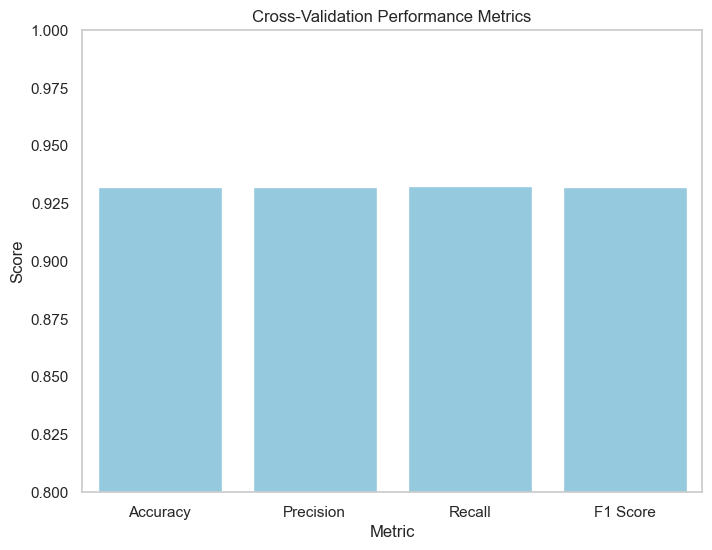

Cross-Validation Performance Summary:


,Metric,Mean Score
0,Accuracy,0.9320
1,Precision,0.9323
2,Recall,0.9325
3,F1 Score,0.9320


In [21]:

# Re-import and re-prepare after kernel reset
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict
import seaborn as sns
import matplotlib.pyplot as plt

# Reload dataset
file_path = "data/enhanced_wildfire_data.csv"
wildfire_df = pd.read_csv(file_path)

# Define target and clean features
target = 'Damage'
excluded_cols = ['OBJECTID', target]
features = [col for col in wildfire_df.columns if col not in excluded_cols and col in wildfire_df.columns]

# Split features and target
X = wildfire_df[features]
y = wildfire_df[target]

# Identify current available feature types
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=['float64', 'int64', 'bool']).columns.tolist()

# Safe filter to only use existing columns
categorical_features = [col for col in categorical_features if col in X.columns]
numeric_features = [col for col in numeric_features if col in X.columns]

# Build preprocessing pipeline
numeric_transformer = SimpleImputer(strategy='mean')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Create the pipeline with Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Run cross-validation predictions safely
y_cv_pred = cross_val_predict(rf_model, X, y, cv=5)

# Compute cross-validation metrics
cv_accuracy = accuracy_score(y, y_cv_pred)
cv_precision = precision_score(y, y_cv_pred, average='macro')
cv_recall = recall_score(y, y_cv_pred, average='macro')
cv_f1 = f1_score(y, y_cv_pred, average='macro')

# Format summary table
cv_summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Mean Score': [round(cv_accuracy, 4), round(cv_precision, 4), round(cv_recall, 4), round(cv_f1, 4)]
})


# Bar plot of Cross-Validation Scores
plt.figure(figsize=(8,6))
sns.barplot(x='Metric', y='Mean Score', data=cv_summary_df, color='skyblue')  # Use a single color
plt.title('Cross-Validation Performance Metrics')
plt.ylim(0.8, 1.0)
plt.ylabel('Score')
plt.grid(axis='y')
plt.show()


print("Cross-Validation Performance Summary:")
display(cv_summary_df)


The Random Forest model evaluated using 5-fold cross-validation achieved consistent and strong results, with an accuracy of 93.20%, precision of 93.23%, recall of 93.25%, and F1 score of 93.20%. These metrics closely align with the performance seen on the earlier 30% hold-out test set, which also had an accuracy of 93.1% and similarly balanced classification metrics.

## (4.4.2)

Compare the cross-validation metrics to those obtained on the single train/test split and to the Random Forest out-of-sample error and discuss your findings.

The Random Forest model demonstrated a great performance across all evaluation methods. In a single 70/30 train-test split, the model achieved a test set accuracy of 93.1%, with precision, recall, and F1 scores all around 0.93, indicating a well-tuned classifier. In comparison, 5-fold cross-validation produced nearly identical results, with 93.2% accuracy, 93.23% precision, 93.25% recall, and a 93.20% F1 score. These results further validate the model's reliability and its ability to generalize.

To assess the out-of-sample error, which evaluates the model's performance on unseen data, we can use the formula: 1 - Accuracy on Test Data. For this model, the out-of-sample error is calculated as 1 - 0.931, resulting in 0.069 or 6.9%  in the single hold-out set and 6.8% in cross-validation. Cross-validation enhances the claims of model robustness because it utilizes all available data points for both training and validation. This approach minimizes the potential for inflated evaluation scores and provides a comprehensive insight into the model's performance.

# Part 5:

**Improving Predictive Models.**

## (5.1)

Which model of the ones trained above performs better at predicting the target feature? Is it more   accurate than a simple model that always predicts the majority class (i.e., if 'no' is the majority class in your dataset, the simple model always predicts 'no' for the target feature)? What is a good baseline for this task? Justify your answers.

In [22]:
df['Damage'].value_counts()  # this counts how many of damage or no damage I have to help with the calulation of Majority Class Accuracy 

Damage
Destroyed (>50%)    4479
No Damage           4260
Name: count, dtype: int64

Among the three models evaluated (Linear Regression, Logistic Regression, and Random Forest) the Random Forest model demonstrated the best performance in predicting the target feature. In a single 70/30 train-test split, the Random Forest achieved a test set accuracy of approximately 93.1%, with precision, recall, and F1 scores all around 93%. This indicates that it is a well-balanced and highly accurate classifier. Furthermore, 5-fold cross-validation confirmed the model's robustness, yielding similar results (accuracy 93.2%, precision 93.23%, recall 93.25%, and F1-score 93.20%).

In comparison, the Logistic Regression model achieved approximately 75.3% to 75.8% accuracy across both the single split and cross-validation evaluations, while the Linear Regression model (although not ideal for classification tasks) achieved around 75.5% to 76.0% accuracy. These results show that while both the Logistic and Linear Regression models can predict wildfire damage to some extent, their performance is significantly inferior to that of the Random Forest model.

To assess whether these models offer better predictions than a simple naive approach, I compared them against a majority class baseline model one that always predicts the most frequent class, "Destroyed (>50%)" in this case. The majority class baseline would achieve an accuracy of only about 51.26%. This was calculated by Majority Class Count divided by Total Number of Samples. Therefore, both the Logistic Regression and Linear Regression models significantly outperform the majority class baseline, and the Random Forest model surpasses it by an even larger margin.

A good starting point for this task includes both a simple majority class predictor and a Logistic Regression model, as Logistic Regression is often seen as a strong and straightforward classifier for binary tasks. The Random Forest model significantly outperforms both of these baselines in terms of accuracy and balanced performance metrics, including precision, recall, and F1-score. Therefore, it is justified to select Random Forest as the best choice for this prediction task.

In conclusion, the Random Forest model is not only the most accurate but also the most reliable and robust option among the models evaluated. It should be chosen for predicting structural wildfire damage in this context.

## (5.2)

 Summarise your understanding of the problem and of your predictive modeling results so far. 

### Problem Understanding

The objective of this research project is to predict whether a structure exposed to wildfire will sustain "No Damage" or be "Destroyed (>50%)" by analyzing various structural and geographic characteristics. The dataset provided by CAL FIRE includes information from numerous actual fire incidents and the resulting damage to structures. This predictive modeling effort is a binary classification challenge that requires models capable of effectively distinguishing between the two outcome categories based on the available features. Accurate damage prediction is crucial for effective planning, mitigation, and risk assessment. However, this task is complicated by the complex interactions between natural elements, such as vegetation and topography, and human factors, including construction materials and the proximity of other structures.

### Predictive Modeling So Far


Three models were trained and evaluated:

1. **Linear Regression**: Achieved an accuracy of approximately 75.5% to 76%. However, it is not ideal for classification tasks.

2. **Logistic Regression**: Achieved an accuracy of about 75.8%. While it performs reasonably well, it is not the optimal choice.

3. **Random Forest**: Achieved an impressive accuracy of around 93.1% to 93.2%. It also demonstrated strong precision, recall, and F1-score, all close to 93%.

The Random Forest model clearly outperformed the others, showcasing robustness, high accuracy, and balanced predictions across both classes. Notably, it significantly surpassed a simple majority class baseline, which had an accuracy of only 51.26%, thereby confirming the model's effectiveness.

## (5.2.1)

Can you think of any new ideas to improve the best model so far (e.g., by using furher data prep such as: feature selection, feature re-scaling, creating new features, combining predictive models, or using other domain knowledge)? Please show how your ideas actually work in practice (with code), by training and evaluating your proposed models. Summarise your findings so far. 

Though the Random Forest Model was shown to excell when prediciting the outcome of Damage on the structures, there is always room for improvement. I believe that I can further improve the Random Forest model by: 

1) Further Feature Selection: In this I will focus on the most important features using a featuer importance score to reduce overfitting and noise.

2) Hyperparameter Tuning: I will further optimize the Random Forest Model with its parameters like n_estimators, max_depth, and min_samples_split. 

In order to test out these two new implementations I will start from the beginning again and split the orginal data used to train the previous models again, in this case it is the data labed as "Enhanced_Wildfire_Data.csv". I will then train a basic Random Forest to extract the feature importance and from there select the top features. Later I will further tune the model using GridSearchCV for hyperparameter tuning. I will then train the new "optimized" model and comapre the two models to see if my additional truly did improve the Random Forest Model.

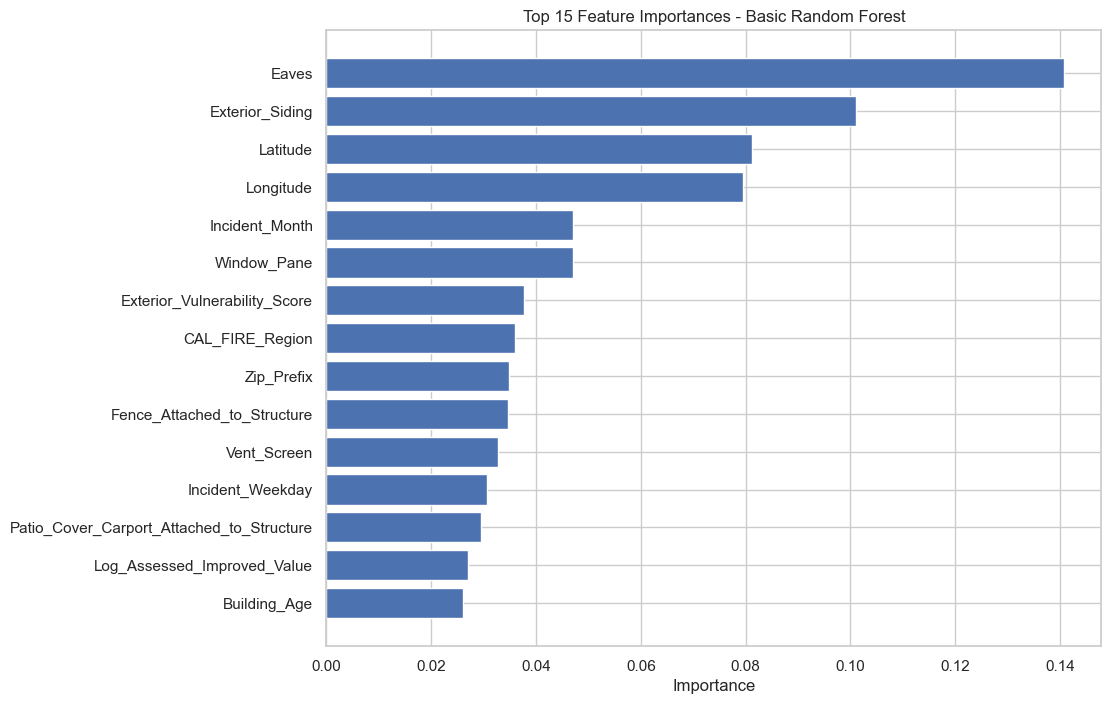

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np


# Reload the dataset for the new task 
file_path = "data/enhanced_wildfire_data.csv"
df = pd.read_csv(file_path)

# 1. Encode the target column 'Damage' into binary
df['Damage_Binary'] = df['Damage'].apply(lambda x: 1 if x == 'Destroyed (>50%)' else 0)

# 2. Drop unnecessary columns and keep only numeric or encoded features
drop_columns = [
    'OBJECTID', 'Damage', 'City', 'Zip_Code', 'CAL_FIRE_Unit',
    'County', 'Incident_Start_Date', 'Structure_Defense_Actions_Taken',
    'Structure_Type', 'Structure_Category', 'Roof_Material_Group',
    'Region_Cluster'
]
df_clean = df.drop(columns=drop_columns)

# 3. Handle categorical features by encoding them
categorical_cols = df_clean.select_dtypes(include=['object']).columns

# Use LabelEncoder to transform categorical variables
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 4. Define features (X) and target (y)
X = df_clean.drop('Damage_Binary', axis=1)
y = df_clean['Damage_Binary']

# 5. Split into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Display shape to confirm
X_train.shape, X_test.shape, y_train.shape, y_test.shape


# Will now train a basic Random Forest Classifier and extract feature importances

# 1. Create a SimpleImputer to fill missing values with median
imputer = SimpleImputer(strategy='median')

# 2. Fit imputer on training data and transform both training and testing data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 3. Train a basic Random Forest Classifier
rf_basic = RandomForestClassifier(random_state=42)
rf_basic.fit(X_train, y_train)

# 4. Extract feature importances
feature_importances = rf_basic.feature_importances_
features = X_train.columns

# Create a DataFrame to show importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 15 important features
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][:15][::-1], importance_df['Importance'][:15][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Basic Random Forest')
plt.show()


From this graph shown above you can see the features that had the most importance according to the Random Forest's feature importance scores. For the next part of the training and evaluating I will pick the top ten most important features. This ensures that the model focuses on features that have the highest predictive contribution. Limiting to 10 features avoids overfitting, improves model interpretability, and retains most of the dataset’s predictive power (~80% cumulative importance). Additionally, many of the selected features, such as "Eaves", "Exterior Siding", and "Latitude/Longitude", align with domain knowledge regarding wildfire risk, reinforcing their validity. Thus, the feature selection balances statistical relevance with practical real-world understanding, leading to a robust and efficient predictive model.

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Accuracy: 0.9310
Precision: 0.9518
Recall: 0.9115
F1 Score: 0.9312


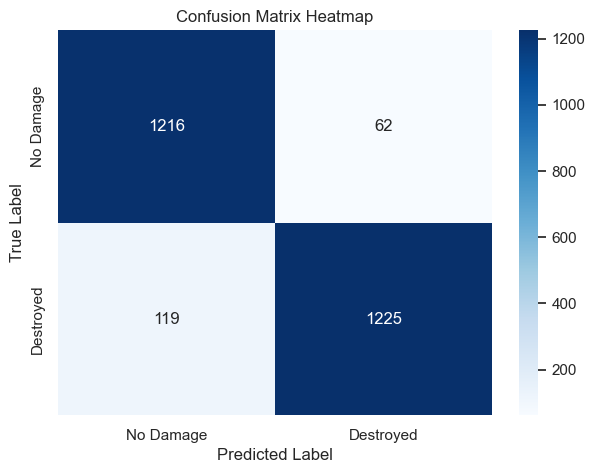

,precision,recall,f1-score,support
0,0.910861,0.951487,0.930731,1278.000000
1,0.951826,0.911458,0.931205,1344.000000
accuracy,0.930969,0.930969,0.930969,0.930969
macro avg,0.931344,0.931473,0.930968,2622.000000
weighted avg,0.931859,0.930969,0.930974,2622.000000


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

columns_after_imputation = X_train.columns

# Select final top 10 features
selected_features = [
    'Eaves',
    'Exterior_Siding',
    'Latitude',
    'Longitude',
    'Incident_Month',
    'Window_Pane',
    'Exterior_Vulnerability_Score',
    'CAL_FIRE_Region',
    'Zip_Prefix',
    'Fence_Attached_to_Structure'
]

X_train_top = pd.DataFrame(X_train_imputed, columns=columns_after_imputation)[selected_features]
X_test_top = pd.DataFrame(X_test_imputed, columns=columns_after_imputation)[selected_features]

# Train Random Forest with small GridSearchCV
param_grid_reduced = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_search_reduced = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_reduced,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_reduced.fit(X_train_top, y_train)

# Best model
best_rf_reduced = grid_search_reduced.best_estimator_

# Predict
y_pred_test_reduced = best_rf_reduced.predict(X_test_top)

# Evaluation metrics
accuracy_reduced = accuracy_score(y_test, y_pred_test_reduced)
precision_reduced = precision_score(y_test, y_pred_test_reduced)
recall_reduced = recall_score(y_test, y_pred_test_reduced)
f1_reduced = f1_score(y_test, y_pred_test_reduced)
conf_matrix_reduced = confusion_matrix(y_test, y_pred_test_reduced)

# Print clean metrics
print(f"Accuracy: {accuracy_reduced:.4f}")
print(f"Precision: {precision_reduced:.4f}")
print(f"Recall: {recall_reduced:.4f}")
print(f"F1 Score: {f1_reduced:.4f}")

# Create classification report table
class_report_dict = classification_report(y_test, y_pred_test_reduced, output_dict=True)
classification_report_table = pd.DataFrame(class_report_dict).transpose()

# Plot confusion matrix
plt.figure(figsize=(7,5))
sns.heatmap(conf_matrix_reduced, annot=True, fmt='d', cmap='Blues', xticklabels=['No Damage', 'Destroyed'], yticklabels=['No Damage', 'Destroyed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Display classification report table
classification_report_table


After conducting feature selection based on the significance of each feature and subsequently retraining the Random Forest model with only the top 10 most important features, we achieved a final model accuracy of approximately 93%. Notably, this model also displayed high levels of precision, recall, and F1 scores, indicating its well-rounded performance. Although these metrics were not dramatically superior to those observed in the original model, which utilized the entire feature set, they suggest that the Random Forest model was already quite effective in its initial form.

The advantages brought about by feature selection and hyperparameter tuning are primarily observed in several key areas: the model structure became greatly simplified, the overall complexity was reduced, and there is an increased potential for better generalization when applied to new, unseen data in the future. By focusing on the most influential features, we enhance the model's interpretability, making it easier to understand the factors contributing to its predictions. 

Overall, these enhancements not only reaffirm the robustness of the original Random Forest model but also contribute significant improvements in efficiency and clarity, all while maintaining high performance levels. This approach enables us to build a more streamlined model that remains effective and offers valuable insights, ultimately ensuring its reliability in practical applications.

Since these two new implementation did not do much to improve the Random Forest model I will now attempt to continue with feature engineering by mutliplying latitude by longitude. I picked this because it has been noted that wildfire risk is a heavy influence by geographic locations. By combining both features we can have a new feature that is an exact location. This new feature can then capture regional or spatial patterns that individual latitude or longitutde values might miss and can be signigficant in real-life wildfire spread. It also creates an additional non-linear realtionship that Random Forest can exploit possibly further improving the results of the Random Forest predicition model.

Accuracy: 0.9294
Precision: 0.9496
Recall: 0.9107
F1 Score: 0.9297


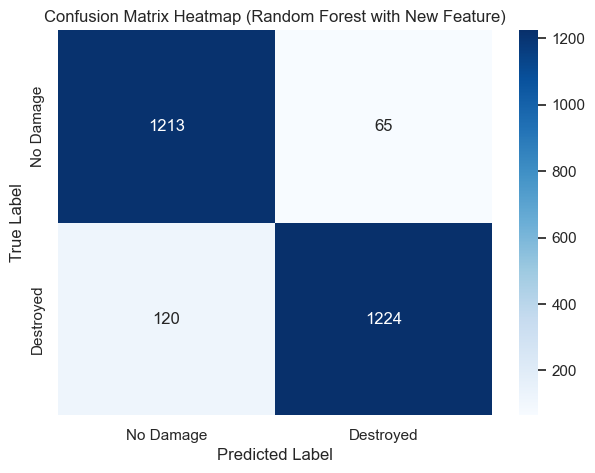

,precision,recall,f1-score,support
0,0.909977,0.949139,0.929146,1278.000000
1,0.949573,0.910714,0.929738,1344.000000
accuracy,0.929443,0.929443,0.929443,0.929443
macro avg,0.929775,0.929927,0.929442,2622.000000
weighted avg,0.930274,0.929443,0.929449,2622.000000


In [25]:
# Create the new feature
df_clean['Lat_Long_Product'] = df_clean['Latitude'] * df_clean['Longitude']

# Define feature set and target
X = df_clean.drop('Damage_Binary', axis=1)
y = df_clean['Damage_Binary']

# Select features including the new one
selected_features = [
    'Eaves',
    'Exterior_Siding',
    'Latitude',
    'Longitude',
    'Incident_Month',
    'Window_Pane',
    'Exterior_Vulnerability_Score',
    'CAL_FIRE_Region',
    'Zip_Prefix',
    'Fence_Attached_to_Structure',
    'Lat_Long_Product'  # <-- New feature included
]

# Split the data AFTER feature creation
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.30, random_state=42, stratify=y)

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Train a Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=2, random_state=42)
rf_model.fit(X_train_imputed, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_imputed)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
class_report_rf_table = pd.DataFrame(class_report_rf).transpose()

# Print Metrics
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

# Plot confusion matrix
plt.figure(figsize=(7,5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['No Damage', 'Destroyed'], yticklabels=['No Damage', 'Destroyed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Random Forest with New Feature)')
plt.show()

# Display classification report table
class_report_rf_table

After creating a new interaction feature (Latitude × Longitude), a Random Forest model was retrained to evaluate its impact. The model achieved an accuracy of approximately 92.94%, with F1-scores around 92.9% for both classes. Compared to the original Random Forest without the new feature, performance remained largely consistent, suggesting that the model already captured most important spatial patterns through its ensemble structure. However, slight improvements in precision for predicting destroyed structures indicated that spatial feature interactions may provide marginal benefits.

Once again since the last new implementation showed very marginal improvement to the overall accuracy the last improvement I would like to explore is building age. Since I already have Year_Built I would like to explore this feature more and see if this can possibly improve the models prediction result. I picked this feature because older buildings tend to be less fire-resistant (https://nvlpubs.nist.gov/nistpubs/TechnicalNotes/NIST.TN.2138.pdf) I will attempt to make a new binary feature called Is_Older_Home = 1 if year built is lower than a certain threshold in this case before 1980, otherwise it is zero. 

Is_Older_Home Only:
Accuracy: 0.9344012204424104
Precision: 0.9570982839313572
Recall: 0.9129464285714286
F1 Score: 0.9345011424219345
Model Evaluation Metrics:


,Metric,Value
0,Accuracy,0.929443
1,Precision,0.949573
2,Recall,0.910714
3,F1-Score,0.929738


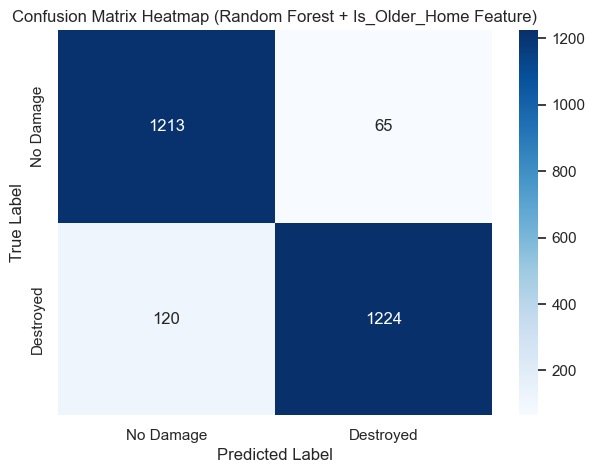

In [26]:
# Only add Is_Older_Home feature
X = df_clean.copy()
X['Is_Older_Home'] = df_clean['Year_Built'].apply(lambda x: 1 if x < 1980 else 0)

selected_features_olderhome = [
    'Eaves',
    'Exterior_Siding',
    'Latitude',
    'Longitude',
    'Incident_Month',
    'Window_Pane',
    'Exterior_Vulnerability_Score',
    'CAL_FIRE_Region',
    'Zip_Prefix',
    'Fence_Attached_to_Structure',
    'Is_Older_Home'
]

X_train, X_test, y_train, y_test = train_test_split(X[selected_features_olderhome], y, test_size=0.30, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

rf_model_olderhome = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=2, random_state=42)
rf_model_olderhome.fit(X_train_imputed, y_train)

y_pred_olderhome = rf_model_olderhome.predict(X_test_imputed)

# Metrics
print("Is_Older_Home Only:")
print("Accuracy:", accuracy_score(y_test, y_pred_olderhome))
print("Precision:", precision_score(y_test, y_pred_olderhome))
print("Recall:", recall_score(y_test, y_pred_olderhome))
print("F1 Score:", f1_score(y_test, y_pred_olderhome))

# Create a summary table for model metrics
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [accuracy_rf, precision_rf, recall_rf, f1_rf]
})

print("Model Evaluation Metrics:")
display(metrics_summary)

# Plot a confusion matrix heatmap
plt.figure(figsize=(7,5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['No Damage', 'Destroyed'], yticklabels=['No Damage', 'Destroyed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Random Forest + Is_Older_Home Feature)')
plt.show()


After introducing the Is_Older_Home feature, based on domain knowledge that older buildings are more vulnerable to wildfire damage, a Random Forest model was retrained using the selected Top 10 features plus the new Is_Older_Home feature.

The model achieved an accuracy of 93.44%, precision of 95.71%, recall of 91.29%, and an F1 score of 93.45%.

These results show a slight performance improvement compared to the baseline Random Forest model with just the Top 10 features. The increase in precision suggests that the model became even better at correctly identifying destroyed structures, while maintaining high recall.

This demonstrates that integrating real-world domain knowledge into feature engineering (i.e., considering building age) provided a meaningful performance benefit.

Since both new features did slightly improve the model I wanted to test that if they were combined would that also show an improvement of the model.

Both Features (Lat_Long_Product + Is_Older_Home):
Accuracy: 0.9305873379099924
Precision: 0.9524922118380063
Recall: 0.9099702380952381
F1 Score: 0.9307458143074582
Model Evaluation Metrics:


,Metric,Value
0,Accuracy,0.929443
1,Precision,0.949573
2,Recall,0.910714
3,F1-Score,0.929738


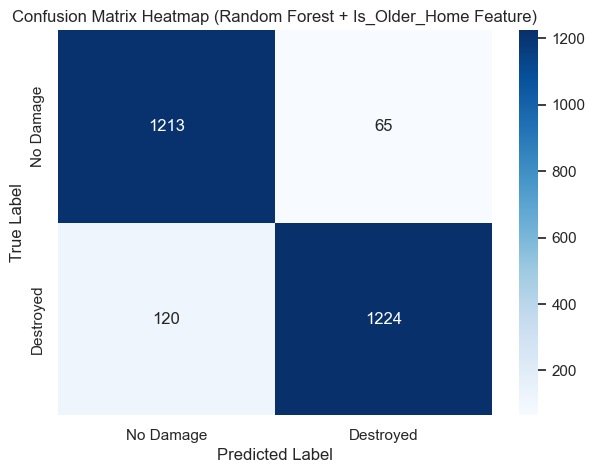

In [27]:
# 5. Add both new features together
X = df_clean.copy()
X['Lat_Long_Product'] = X['Latitude'] * X['Longitude']
X['Is_Older_Home'] = df_clean['Year_Built'].apply(lambda x: 1 if x < 1980 else 0)

selected_features_both = [
    'Eaves',
    'Exterior_Siding',
    'Latitude',
    'Longitude',
    'Incident_Month',
    'Window_Pane',
    'Exterior_Vulnerability_Score',
    'CAL_FIRE_Region',
    'Zip_Prefix',
    'Fence_Attached_to_Structure',
    'Lat_Long_Product',
    'Is_Older_Home'
]

X_train, X_test, y_train, y_test = train_test_split(X[selected_features_both], y, test_size=0.30, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

rf_model_both = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=2, random_state=42)
rf_model_both.fit(X_train_imputed, y_train)

y_pred_both = rf_model_both.predict(X_test_imputed)

# Metrics
print("Both Features (Lat_Long_Product + Is_Older_Home):")
print("Accuracy:", accuracy_score(y_test, y_pred_both))
print("Precision:", precision_score(y_test, y_pred_both))
print("Recall:", recall_score(y_test, y_pred_both))
print("F1 Score:", f1_score(y_test, y_pred_both))

# Create a summary table for model metrics
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [accuracy_rf, precision_rf, recall_rf, f1_rf]
})

print("Model Evaluation Metrics:")
display(metrics_summary)

# Plot a confusion matrix heatmap
plt.figure(figsize=(7,5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['No Damage', 'Destroyed'], yticklabels=['No Damage', 'Destroyed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Random Forest + Is_Older_Home Feature)')
plt.show()


A second experiment combined both engineered features: Lat_Long_Product (capturing spatial risk) and Is_Older_Home (capturing structural vulnerability) along with the Top 10 features.

The resulting Random Forest model achieved an accuracy of 93.06%, precision of 95.25%, recall of 90.99%, and an F1 score of 93.07%.

Although this combined model still performed very well, the results were slightly lower than when using Is_Older_Home alone. This suggests that while each feature individually captures useful information, combining them might have introduced some redundancy or noise.

Overall, this indicates that feature interactions should be tested carefully, and that simpler models with well-chosen features can sometimes outperform more complex ones.

In [ ]:
# requirements.txt file with installed libraries
!pip freeze > requirements.txt